# LAB6

**Disclosure:**

> HAIL `LEVEL 3`: In this Laboratory, I use `Codex` to help me to correct the code, and for complete the code faster, I search for `copilot`.

For Bonus, I tell `Codex` my thought process, and `Codex` help me finish the function. I search the best parameters later.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

## Project 1 Similarity Measure

### 1.1 Extract and plot one coronal slice from two modalities.

完成一些必要的辅助函数，包括：
- 切片      `imageSlice`
- 归一化    `imageNormalization`
- 添加 mask `imageMask`
- 图像展示  `show_images_L1`

In [2]:
def imageSlice(image, idx: int = 120):
    """ slice the coronal plane """
    return image[:, idx, :]



def imageNormalization(image):
    """ normalize image to [0, 1] """
    image = image.astype(np.float64)
    image_min = np.min(image)
    image_max = np.max(image)
    if image_max == image_min:
        return np.zeros_like(image)
    return (image - image_min) / (image_max - image_min)



def imageMask(image, mask):
    """ apply mask to image """
    return image * mask



def show_images_L1(images, titles, cmap='gray'):
    """ show images in a row """
    n = len(images)
    plt.figure(figsize=(n * 3, 5))
    for i, (img, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(1, n, i)
        plt.imshow(img, cmap=cmap)
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

选取 `y = 120` 的层面，该层具有良好的大脑切片结构。

Image T1w:
Shape: (300, 208)
Data type: float64
MAX value: 414.0
MIN value: 0.0

Image T2w:
Shape: (300, 208)
Data type: float64
MAX value: 305.0
MIN value: 0.0


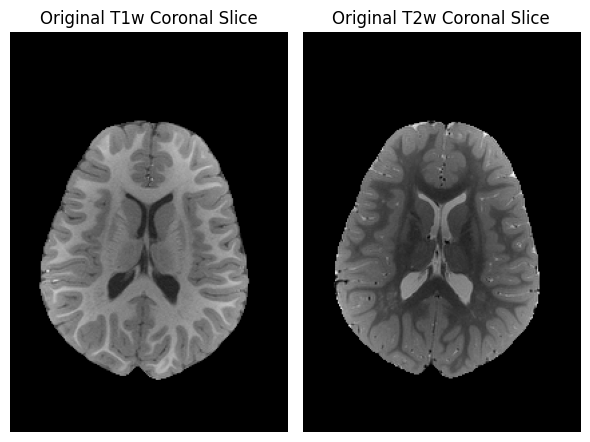

In [3]:
# test
t1_img = nib.load("input/T1w.nii")
t2_img = nib.load("input/T2w.nii")
t1_data = t1_img.get_fdata()
t2_data = t2_img.get_fdata()

coronal_idx = 120
t1_coronal = imageSlice(t1_data, coronal_idx)
t2_coronal = imageSlice(t2_data, coronal_idx)

# print the information of the images
print("Image T1w:")
print("Shape:", t1_coronal.shape)
print("Data type:", t1_coronal.dtype)
print("MAX value:", t1_coronal.max())
print("MIN value:", t1_coronal.min())
print("\nImage T2w:")
print("Shape:", t2_coronal.shape)
print("Data type:", t2_coronal.dtype)
print("MAX value:", t2_coronal.max())
print("MIN value:", t2_coronal.min())

# show the original images
show_images_L1(
    images=[t1_coronal, t2_coronal],
    titles=["Original T1w Coronal Slice", "Original T2w Coronal Slice"]
)

### 1.2 Write function for calculating the similarity metrics (SSD, RIU, CC, and MI) manually between the two slices, then comparing with standard library (except RIU)

write the function `SSD`, `RIU`, `CC`, `MI` first.

In [4]:
def calc_SSD(image1, image2, mask):
    """ calculate sum of squared differences """
    image1 = image1[mask]
    image2 = image2[mask]
    return np.sum((image1 - image2) ** 2)


def calc_RIU(image1, image2, mask):
    """ calculate ratio image uniformity """
    if np.sum(mask) == 0:
        return np.inf
    eps = 1e-8
    ratio = image1[mask] / (image2[mask] + eps)
    ratio_mean = np.mean(ratio)
    if ratio_mean == 0:
        return np.inf
    return np.std(ratio) / ratio_mean


def calc_CC(image1, image2, mask):
    """ calculate correlation coefficient """
    image1 = image1[mask]
    image2 = image2[mask]
    image1_centered = image1 - np.mean(image1)
    image2_centered = image2 - np.mean(image2)
    denominator = np.sqrt(np.sum(image1_centered ** 2) * np.sum(image2_centered ** 2))
    if denominator == 0:
        return 0
    return np.sum(image1_centered * image2_centered) / denominator


def calc_MI(image1, image2, mask, bins: int = 64):
    """ calculate mutual information """
    image1 = image1[mask]
    image2 = image2[mask]
    joint_hist, _, _ = np.histogram2d(image1.ravel(), image2.ravel(), bins=bins)
    if np.sum(joint_hist) == 0:
        return 0
    joint_prob = joint_hist / np.sum(joint_hist)
    image1_prob = np.sum(joint_prob, axis=1)
    image2_prob = np.sum(joint_prob, axis=0)
    nonzero = joint_prob > 0
    return np.sum(joint_prob[nonzero] * np.log(joint_prob[nonzero] / (image1_prob[:, None] * image2_prob[None, :])[nonzero]))

In [5]:
# test similarity metrics
t1_normalized = imageNormalization(t1_coronal)
t2_normalized = imageNormalization(t2_coronal)
mask = (t1_normalized > 0) & (t2_normalized > 0)

similarity_results = {
    "T1w vs T1w": {
        "SSD": calc_SSD(t1_normalized, t1_normalized, mask),
        "RIU": calc_RIU(t1_normalized, t1_normalized, mask),
        "CC": calc_CC(t1_normalized, t1_normalized, mask),
        "MI": calc_MI(t1_normalized, t1_normalized, mask),
    },
    "T1w vs T2w": {
        "SSD": calc_SSD(t1_normalized, t2_normalized, mask),
        "RIU": calc_RIU(t1_normalized, t2_normalized, mask),
        "CC": calc_CC(t1_normalized, t2_normalized, mask),
        "MI": calc_MI(t1_normalized, t2_normalized, mask),
    }
}


# print the similarity results
for pair_name, metrics in similarity_results.items():
    print(f"{pair_name}: ")
    print("=" * 30)
    for metric_name, value in metrics.items():
        print(f"{metric_name:<10}\t{value:<20.6f}")
    print("=" * 30)
    print()

T1w vs T1w: 
SSD       	0.000000            
RIU       	0.000000            
CC        	1.000000            
MI        	3.388662            

T1w vs T2w: 
SSD       	984.818634          
RIU       	0.523097            
CC        	-0.123366           
MI        	0.333275            



先看 T1w 与自身的相似性指标：
- `SSD = 0`, 两张图完全相同
- `RIU = 0`, 两张图完全相同
- `CC = 1`, 两张图完全正相关（也就是完全相同）
- `MI = 3.388662`, 完全相同的两张图能够达到的最大互信息量为 3.388662

在此基础上可以来查看 T1w 和 T2w 之间的相似性指标：
- `SSD = 984.818634`, 两张图差异很大，主要是两张图对比度特性基本相反，所有 SSD 会特别大
- `RIU = 0.523097`, 比值有一定区别，可能是 T1 和 T2 关注的区域不同
- `CC = -0.123366`, 两张图呈现轻微的负相关，也就是强度相反，复合实际情况
- `MI = 0.333275`, 小于最大互信息量 3.388662，说明两者的共享信息挺少的（共享的有可能是边缘信息？）

### 1.3 Comparing with standard library (except RIU).

调用已有的标准库来实现 `SSD`, `CC`, `MI`。但是由于用的不是同一个库，之后调用不太方便，因此还是封装一下，组成 `standard` 函数组。

In [6]:
# Use standard library: SSD, CC, MI
from scipy.spatial.distance import sqeuclidean
from scipy.stats import pearsonr
from sklearn.metrics import mutual_info_score


def standard_SSD(image1, image2, mask):
    """ calculate SSD with scipy """
    image1 = image1[mask].ravel()
    image2 = image2[mask].ravel()
    return sqeuclidean(image1, image2)


def standard_CC(image1, image2, mask):
    """ calculate CC with scipy """
    image1 = image1[mask].ravel()
    image2 = image2[mask].ravel()
    return pearsonr(image1, image2)[0]


def standard_MI(image1, image2, mask, bins: int = 64):
    """ calculate MI with sklearn """
    image1 = image1[mask].ravel()
    image2 = image2[mask].ravel()
    joint_hist, _, _ = np.histogram2d(image1, image2, bins=bins)
    return mutual_info_score(None, None, contingency=joint_hist)


def compare_metrics(image1, image2, mask):
    return {
        "SSD": {
            "My": calc_SSD(image1, image2, mask),
            "Standard Library": standard_SSD(image1, image2, mask),
        },
        "CC": {
            "My": calc_CC(image1, image2, mask),
            "Standard Library": standard_CC(image1, image2, mask),
        },
        "MI": {
            "My": calc_MI(image1, image2, mask),
            "Standard Library": standard_MI(image1, image2, mask),
        },
    }


def print_compare_table(title, results):
    print(f"{title}:")
    print("=" * 50)
    print(f"{'Metric':<10}{'My':<20}{'Standard Library':<20}")
    print("-" * 50)
    for metric_name, values in results.items():
        print(f"{metric_name:<10}{values['My']:<20.6f}{values['Standard Library']:<20.6f}")
    print("=" * 50)
    print()


t1_t1_mask = t1_normalized > 0
t1_t2_mask = (t1_normalized > 0) & (t2_normalized > 0)

t1_t1_results = compare_metrics(t1_normalized, t1_normalized, t1_t1_mask)
t1_t2_results = compare_metrics(t1_normalized, t2_normalized, t1_t2_mask)

print_compare_table("T1w vs T1w", t1_t1_results)
print_compare_table("T1w vs T2w", t1_t2_results)


T1w vs T1w:
Metric    My                  Standard Library    
--------------------------------------------------
SSD       0.000000            0.000000            
CC        1.000000            1.000000            
MI        3.375433            3.375433            

T1w vs T2w:
Metric    My                  Standard Library    
--------------------------------------------------
SSD       984.818634          984.818634          
CC        -0.123366           -0.123366           
MI        0.333275            0.333275            



从输出结果上来看，在 `SSD`, `CC`, `MI` 这几个指标上，自己写的函数和标准库的结果没有什么差异。

## Project 2 Image Registration

### 2.1 Apply known rigid transformation (rotation and translation) to the T1w&T2w image.

刚性运动的思路有两种，一个是直接对切片的 2D 图像进行运动操作，也可以先对 3D 图像进行对应运动，然后再切片。从实验结果来看，直接对 2D 切片图像操作简单、省时又不容易出错。因此直接变换切片后的 2D 图像。

Applied rigid transformation on 2D coronal slices:
Rotation: 15 degrees
Translation: (10, -5) pixels


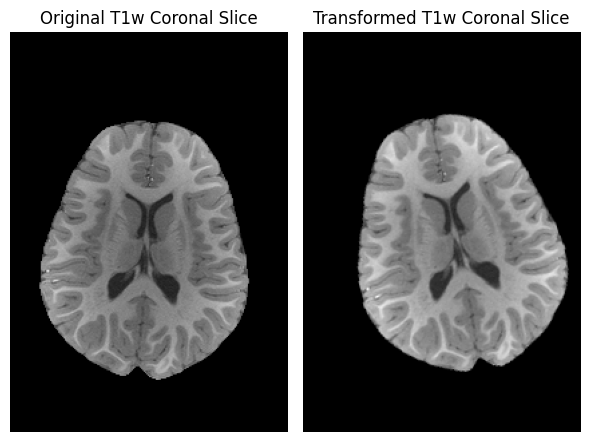

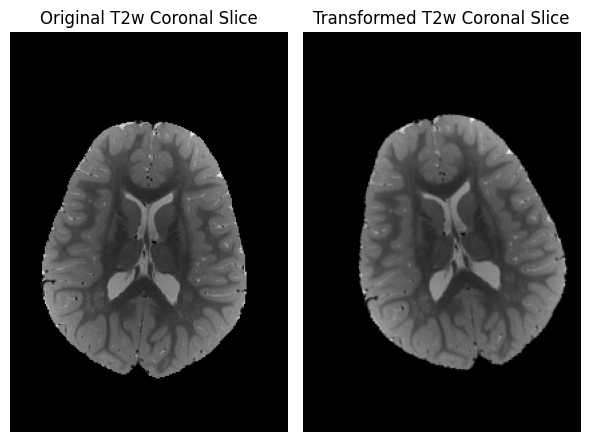

In [7]:
from scipy.ndimage import rotate, shift

# demand transformation: rotate 15 degrees and shift (10, -5)
rotation_angle = 15
shift_x = 10
shift_y = -5


def apply_transform_2d(image, angle, translation: tuple = (0, 0)):
    """ apply rigid transformation to a 2D coronal slice """
    rotated_image = rotate(
        image,
        angle=angle,
        reshape=False,
        order=1,
        mode="constant",
        cval=0.0
    )
    transformed_image = shift(
        rotated_image,
        shift=translation,
        order=1,
        mode="constant",
        cval=0.0
    )
    return transformed_image


t1_transformed_coronal = apply_transform_2d(
    t1_coronal, rotation_angle, (shift_y, shift_x)
)
t2_transformed_coronal = apply_transform_2d(
    t2_coronal, rotation_angle, (shift_y, shift_x)
)

print("Applied rigid transformation on 2D coronal slices:")
print(f"Rotation: {rotation_angle} degrees")
print(f"Translation: ({shift_x}, {shift_y}) pixels")

show_images_L1(
    images=[t1_coronal, t1_transformed_coronal],
    titles=["Original T1w Coronal Slice", "Transformed T1w Coronal Slice"]
)

show_images_L1(
    images=[t2_coronal, t2_transformed_coronal],
    titles=["Original T2w Coronal Slice", "Transformed T2w Coronal Slice"]
)


这里要注意，由于 `numpy` 中处理图像将第一维作为纵向，第二维作为横向。因此如果想要实现 `shift (10, -5)` 则需要将 `shift_x` 作为第二维，`shift_y` 作为第一维，也就是平移的时候采用 `(shift_y, shift_x)`。

### 2.2 Register the transformed images back to the target T1 image

为了实现针对不同相似性度量指标的 SGD 优化，需要先实现一些辅助函数：
- 计算指标 `metric`
- 计算损失 `loss`
- 计算梯度 `gradient`
- 施加变换

接下来先实现以上辅助函数。

In [8]:
# basic function cell
def calculate_metric(
    fixed_image, moving_image, mask, 
    metric="SSD", 
    bins: int = 64
):
    """ calculate similarity metric between fixed image and moving image """

    metric = metric.upper()
    if metric == "SSD":
        return calc_SSD(fixed_image, moving_image, mask)
    if metric == "RIU":
        return calc_RIU(fixed_image, moving_image, mask)
    if metric == "CC":
        return calc_CC(fixed_image, moving_image, mask)
    if metric == "MI":
        return calc_MI(fixed_image, moving_image, mask, bins=bins)
    
    raise ValueError("metric should be one of: SSD, RIU, CC, MI")


def calculate_loss(
    fixed_image, moving_image, mask, 
    metric="SSD", 
    bins: int = 64
):
    """ calculate loss for optimization """
    metric = metric.upper()
    metric_value = calculate_metric(fixed_image, moving_image, mask, metric, bins)

    if metric == "SSD":
        valid_count = np.sum(mask)
        if valid_count == 0:
            return np.inf
        return metric_value / valid_count
    else:
        return -metric_value


def calculate_gradient(
    fixed_image, moving_image, mask,
    params: tuple = (0, 0, 0),
    metric="SSD",
    bins: int = 64,
    eps=(0.5, 1.0, 1.0)
):
    """ calculate numerical gradient by central difference """
    params = np.array(params, dtype=np.float64)
    gradient = np.zeros_like(params)

    for i, step in enumerate(eps):
        params_plus = params.copy()
        params_minus = params.copy()
        params_plus[i] += step
        params_minus[i] -= step
        image_plus = apply_registration_transform(moving_image, params_plus)
        image_minus = apply_registration_transform(moving_image, params_minus)
        loss_plus = calculate_loss(fixed_image, image_plus, mask, metric, bins)
        loss_minus = calculate_loss(fixed_image, image_minus, mask, metric, bins)
        gradient[i] = (loss_plus - loss_minus) / (2 * step)
        if not np.isfinite(gradient[i]):
            gradient[i] = 0

    return gradient



def apply_registration_transform(image, params: tuple = (0, 0, 0)):
    """ apply current 2D rigid transformation """
    angle, shift_y, shift_x = params
    return apply_transform_2d(image, angle, (shift_y, shift_x))


在此基础上就可以写一个主训练的 SGD 函数，通过调用以上辅助函数，完成一个周期的任务。并循环优化任务，完成图像的 SGD 全过程。

In [9]:
# function cell
def steepest_descent_registration(
    fixed_image, 
    moving_image, 
    mask, 
    initial_params=(0.0, 0.0, 0.0), 
    metric="SSD", 
    bins: int = 64,
    max_iter: int = 100,
    learning_rate: float = 2.0,
    gradient_eps=(0.5, 1.0, 1.0),
    tolerance: float = 1e-6,
    line_search_steps: int = 1
):
    """ register moving image to fixed image by steepest descent """

    fixed_image = imageNormalization(fixed_image)
    moving_image = imageNormalization(moving_image)
    params = np.array(initial_params, dtype=np.float64)
    history = []

    print(f"Use metric: {metric.upper()}")
    print(f"{'Iter':<6}{'Loss':>14}{'Metric':>14}{'Angle':>12}{'Shift_y':>12}{'Shift_x':>12}{'Grad norm':>14}")
    print("-" * 84)

    for iteration in range(max_iter + 1):
        transformed_image = apply_registration_transform(moving_image, params)
        current_loss = calculate_loss(fixed_image, transformed_image, mask, metric, bins)
        current_metric = calculate_metric(fixed_image, transformed_image, mask, metric, bins)

        gradient = calculate_gradient(
            fixed_image,
            moving_image,
            mask,
            params,
            metric=metric,
            bins=bins,
            eps=gradient_eps
        )
        grad_norm = np.linalg.norm(gradient)

        history.append({
            "iter": iteration,
            "loss": current_loss,
            "metric": current_metric,
            "params": params.copy(),
            "gradient": gradient.copy(),
        })

        if iteration % 5 == 0:
            print(
                f"{iteration:<6}{current_loss:>14.6f}{current_metric:>14.6f}"
                f"{params[0]:>12.4f}{params[1]:>12.4f}{params[2]:>12.4f}{grad_norm:>14.6f}"
            )

        if not np.isfinite(current_loss):
            print("Stop: loss is not finite.")
            break

        if iteration == max_iter or grad_norm < tolerance:
            break

        step_size = learning_rate
        updated = False
        for _ in range(line_search_steps):
            best_candidate_loss = current_loss
            best_candidate_params = params.copy()

            for direction in (-1, 1):
                candidate_params = params + direction * step_size * gradient
                candidate_image = apply_registration_transform(moving_image, candidate_params)
                candidate_loss = calculate_loss(fixed_image, candidate_image, mask, metric, bins)

                if candidate_loss < best_candidate_loss:
                    best_candidate_loss = candidate_loss
                    best_candidate_params = candidate_params

            if best_candidate_loss < current_loss:
                params = best_candidate_params
                updated = True
                break

            step_size *= 0.5

        if not updated:
            print("Stop: loss no longer decreases.")
            print(f"Last step size: {step_size:.8f}")
            print(f"Gradient: {gradient}")
            break

    registered_image = apply_registration_transform(moving_image, params)
    return registered_image, params, history


接下来对不同图像、不同模态、基于不同的相似度指标来进行优化。

#### 2.2.1 T1w & T1w SSD

Use metric: SSD
Iter            Loss        Metric       Angle     Shift_y     Shift_x     Grad norm
------------------------------------------------------------------------------------
0           0.056317   1307.014024      0.0000      0.0000      0.0000      0.002157
5           0.050783   1178.576069     -0.9005      1.1752     -1.4737      0.001793
10          0.048190   1118.400658     -1.4504      2.0835     -2.7966      0.001594
15          0.045370   1052.950448     -2.0642      2.7536     -4.1587      0.001750
20          0.041725    968.360837     -2.9300      3.3234     -5.6817      0.001888
25          0.038290    888.638167     -4.0210      3.7885     -7.1747      0.001944
30          0.034585    802.641398     -5.3618      4.0011     -8.5500      0.001991
35          0.030517    708.247585     -6.9552      4.0577     -9.8169      0.002155
40          0.025732    597.183024     -8.8648      4.1278    -10.8266      0.002222
45          0.019799    459.489628    -11.1540   

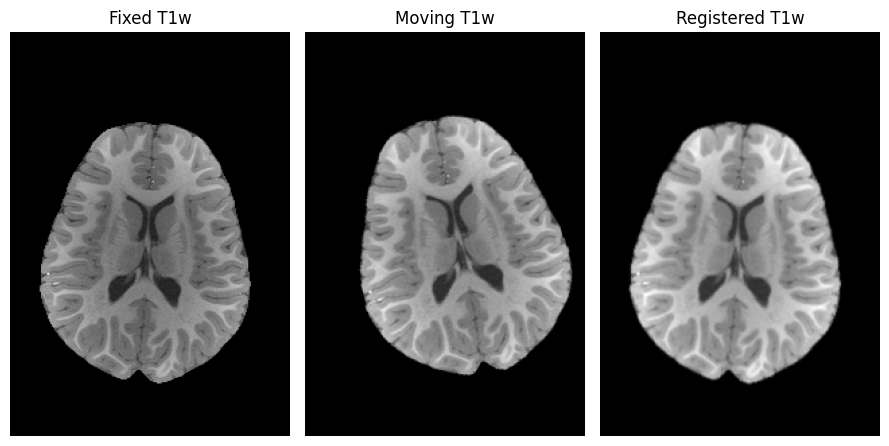

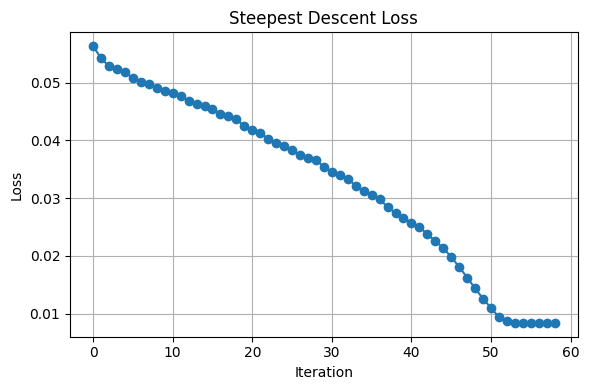

In [11]:
# test cell
fixed_image = imageNormalization(t1_coronal)
moving_image = imageNormalization(t1_transformed_coronal)
registration_mask = fixed_image > 0

registered_t1_coronal_ssd, best_params, registration_history = steepest_descent_registration(
    fixed_image=fixed_image,
    moving_image=moving_image,
    mask=registration_mask,
    initial_params=(0.0, 0.0, 0.0),
    metric="SSD",
    max_iter=100,
    learning_rate=200.0,
    gradient_eps=(0.2, 0.5, 0.5)
)

best_params_t1_ssd = best_params.copy()
registration_history_t1_ssd = registration_history


print("Best registration params:")
print(f"Angle: {best_params[0]:.4f} degrees")
print(f"Shift_y: {best_params[1]:.4f} pixels")
print(f"Shift_x: {best_params[2]:.4f} pixels")

show_images_L1(
    images=[fixed_image, moving_image, registered_t1_coronal_ssd],
    titles=["Fixed T1w", "Moving T1w", "Registered T1w"]
)

loss_history = [item["loss"] for item in registration_history]
plt.figure(figsize=(6, 4))
plt.plot(loss_history, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Steepest Descent Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


可以清晰看到在 50 ~ 60 个 epoch 之后 loss 基本已经收敛。从结果来看，`Angle`, `SHift_y`, `Shift_x` 基本刚好是刚性变换的相反数，结果复合预期。

#### 2.2.2 T1w & T1w RIU

Use metric: RIU
Iter            Loss        Metric       Angle     Shift_y     Shift_x     Grad norm
------------------------------------------------------------------------------------
0          -4.198422      4.198422    -20.0000      0.5000     -1.0000      0.373960
5         -57.830206     57.830206    -16.2827      0.8218    -10.7258    137.801458
10       -152.283261    152.283261    -14.9885      0.5823    -10.4524    329.742680
15       -152.283408    152.283408    -14.9979      0.5869    -10.4488    419.356541
Stop: loss no longer decreases.
Last step size: 0.00000001
Gradient: [-372.89964079  151.66608148  117.48709662]
Best registration params with RIU:
Angle: -14.9979 degrees
Shift_y: 0.5869 pixels
Shift_x: -10.4488 pixels


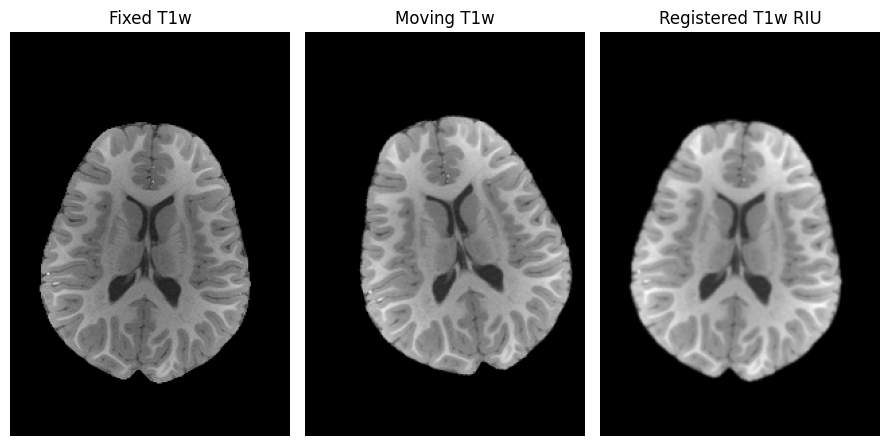

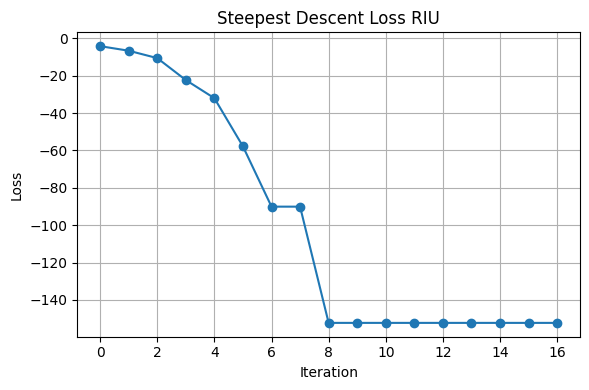

In [12]:
# test cell: RIU
fixed_image = imageNormalization(t1_coronal)
moving_image = imageNormalization(t1_transformed_coronal)
registration_mask = fixed_image > 0

registered_t1_coronal_riu, best_params_riu, registration_history_riu = steepest_descent_registration(
    fixed_image=fixed_image,
    moving_image=moving_image,
    mask=registration_mask,
    initial_params=(-20.0, 0.5, -1.0),
    metric="RIU",
    max_iter=50,
    learning_rate=10,
    gradient_eps=(0.2, 0.5, 0.5),
    line_search_steps=30
)

best_params_t1_riu = best_params_riu.copy()
registration_history_t1_riu = registration_history_riu


print("Best registration params with RIU:")
print(f"Angle: {best_params_riu[0]:.4f} degrees")
print(f"Shift_y: {best_params_riu[1]:.4f} pixels")
print(f"Shift_x: {best_params_riu[2]:.4f} pixels")

show_images_L1(
    images=[fixed_image, moving_image, registered_t1_coronal_riu],
    titles=["Fixed T1w", "Moving T1w", "Registered T1w RIU"]
)

loss_history_riu = [item["loss"] for item in registration_history_riu]
plt.figure(figsize=(6, 4))
plt.plot(loss_history_riu, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Steepest Descent Loss RIU")
plt.grid(True)
plt.tight_layout()
plt.show()


用 `RIU` 作为指标的时候，会发现初始优化值会对优化结果造成很大的影响。而且在优化过程中，由于梯度的值非常大，导致必须用很小的学习率才行。为了让学习率自适应，加入参数 `line_search_steps` 实现二分学习率的自适应。

#### 2.2.3 T1w & T1w CC

Use metric: CC
Iter            Loss        Metric       Angle     Shift_y     Shift_x     Grad norm
------------------------------------------------------------------------------------
0          -0.048890      0.048890      0.0000      0.0000      0.0000      0.017424
5          -0.103456      0.103456     -2.4350      3.6203     -2.4164      0.007958
10         -0.466706      0.466706    -10.2168      5.0819     -9.2792      0.061123
15         -0.978888      0.978888    -15.0223      2.3107    -10.9551      0.004664
20         -0.979382      0.979382    -15.0319      2.2910    -10.9698      0.006558
Stop: loss no longer decreases.
Last step size: 0.09765625
Gradient: [-0.00540633  0.00016306 -0.00293029]
Best registration params:
Angle: -15.0300 degrees
Shift_y: 2.2909 pixels
Shift_x: -10.9688 pixels


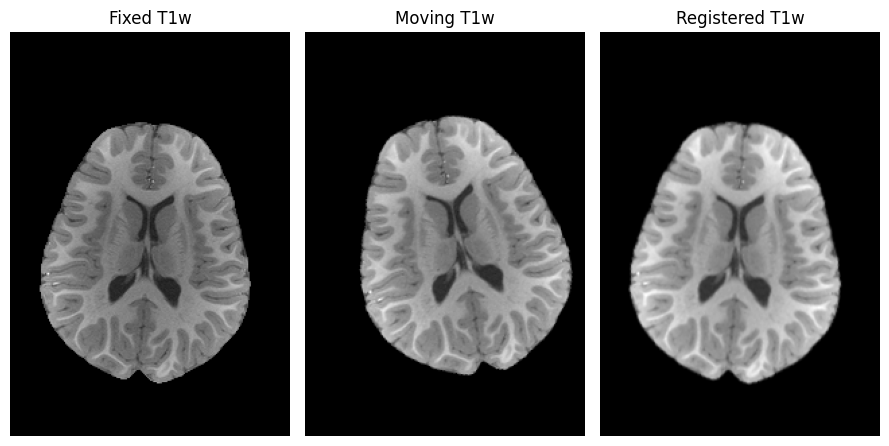

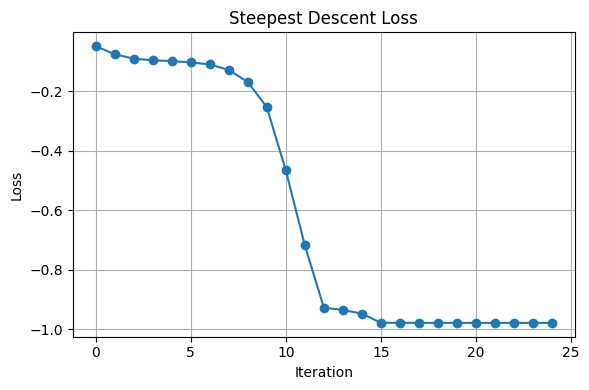

In [13]:
# test cell
fixed_image = imageNormalization(t1_coronal)
moving_image = imageNormalization(t1_transformed_coronal)
registration_mask = fixed_image > 0

registered_t1_coronal_cc, best_params, registration_history = steepest_descent_registration(
    fixed_image=fixed_image,
    moving_image=moving_image,
    mask=registration_mask,
    initial_params=(0.0, 0.0, 0.0),
    metric="CC",
    max_iter=50,
    learning_rate=100.0,
    gradient_eps=(0.5, 1.0, 1.0),
    line_search_steps=10
)

best_params_t1_cc = best_params.copy()
registration_history_t1_cc = registration_history


print("Best registration params:")
print(f"Angle: {best_params[0]:.4f} degrees")
print(f"Shift_y: {best_params[1]:.4f} pixels")
print(f"Shift_x: {best_params[2]:.4f} pixels")

show_images_L1(
    images=[fixed_image, moving_image, registered_t1_coronal_cc],
    titles=["Fixed T1w", "Moving T1w", "Registered T1w"]
)

loss_history = [item["loss"] for item in registration_history]
plt.figure(figsize=(6, 4))
plt.plot(loss_history, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Steepest Descent Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


基于 `CC` 的配准参数算出来和 `SSD` 为指标的优化基本一致。

接下来是 T1w 作为 fix image 和移动过后的 T2w 作为 moving image 之间的跨模态配准。

#### 2.2.4 T1w & T2w SSD

Use metric: SSD
Iter            Loss        Metric       Angle     Shift_y     Shift_x     Grad norm
------------------------------------------------------------------------------------
0           0.066190   1536.142399      0.0000      0.0000      0.0000      0.001973
5           0.060539   1404.983044     -0.8896      0.8330     -1.7843      0.002186
10          0.055559   1289.410605     -1.6046      1.7039     -3.6660      0.002192
15          0.051255   1189.537470     -2.1806      2.5065     -5.4812      0.001789
20          0.049139   1140.409377     -2.7110      3.0789     -6.9096      0.001438
25          0.047016   1091.143263     -3.3033      3.5624     -8.0682      0.001242
30          0.045917   1065.637140     -3.8367      3.8498     -8.8019      0.001049
35          0.045917   1065.636671     -3.8332      3.8482     -8.7977      0.001051
Stop: loss no longer decreases.
Last step size: 0.00019073
Gradient: [ 0.00063704 -0.00029437  0.0007822 ]
Best registration params:
A

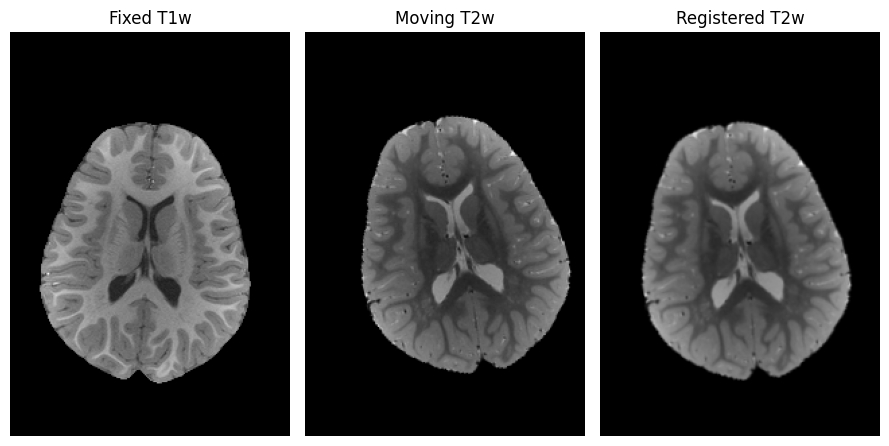

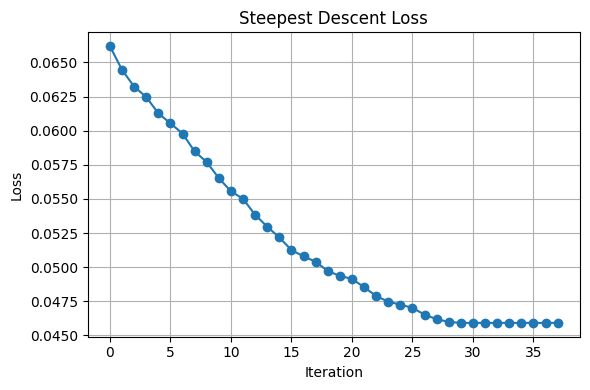

In [14]:
# test cell
fixed_image = imageNormalization(t1_coronal)
moving_image = imageNormalization(t2_transformed_coronal)
registration_mask = fixed_image > 0

registered_t2_coronal_ssd, best_params, registration_history = steepest_descent_registration(
    fixed_image=fixed_image,
    moving_image=moving_image,
    mask=registration_mask,
    initial_params=(0.0, 0.0, 0.0),
    metric="SSD",
    max_iter=100,
    learning_rate=200.0,
    gradient_eps=(0.2, 0.5, 0.5),
    line_search_steps=20
)

best_params_t2_ssd = best_params.copy()
registration_history_t2_ssd = registration_history


print("Best registration params:")
print(f"Angle: {best_params[0]:.4f} degrees")
print(f"Shift_y: {best_params[1]:.4f} pixels")
print(f"Shift_x: {best_params[2]:.4f} pixels")

show_images_L1(
    images=[fixed_image, moving_image, registered_t2_coronal_ssd],
    titles=["Fixed T1w", "Moving T2w", "Registered T2w"]
)

loss_history = [item["loss"] for item in registration_history]
plt.figure(figsize=(6, 4))
plt.plot(loss_history, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Steepest Descent Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


#### 2.2.5 T1w & T2w RIU

Use metric: RIU
Iter            Loss        Metric       Angle     Shift_y     Shift_x     Grad norm
------------------------------------------------------------------------------------
0          -5.282724      5.282724    -20.0000      0.5000     -5.0000      0.730361
5         -20.255384     20.255384    -15.8626      1.7606    -11.7016     17.568063
10       -107.692207    107.692207    -14.1909      2.8685    -11.6389    112.011992
15       -152.201559    152.201559    -14.5751      2.2947    -11.3161    243.949994
20       -152.201736    152.201736    -14.5642      2.2864    -11.3056    243.241777
Stop: loss no longer decreases.
Last step size: 0.00000001
Gradient: [ 154.42616384 -116.14285893  147.74964672]
Best registration params with RIU:
Angle: -14.5642 degrees
Shift_y: 2.2864 pixels
Shift_x: -11.3056 pixels


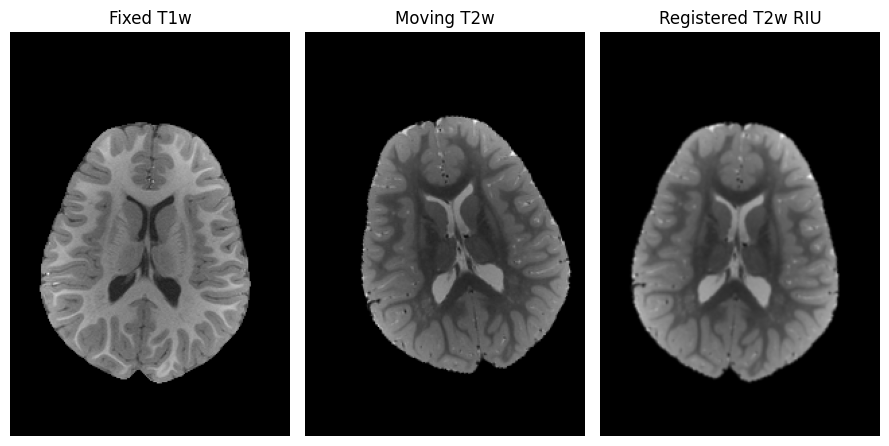

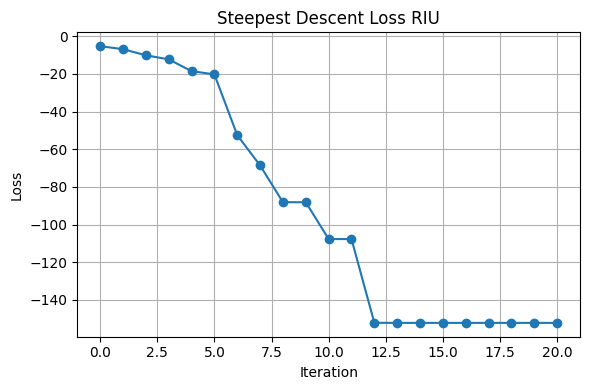

In [15]:
# test cell: RIU
fixed_image = imageNormalization(t1_coronal)
moving_image = imageNormalization(t2_transformed_coronal)
registration_mask = fixed_image > 0

registered_t2_coronal_riu, best_params_riu, registration_history_riu = steepest_descent_registration(
    fixed_image=fixed_image,
    moving_image=moving_image,
    mask=registration_mask,
    initial_params=(-20.0, 0.5, -5.0),
    metric="RIU",
    max_iter=50,
    learning_rate=10,
    gradient_eps=(0.2, 0.5, 0.5),
    line_search_steps=30
)

best_params_t2_riu = best_params_riu.copy()
registration_history_t2_riu = registration_history_riu


print("Best registration params with RIU:")
print(f"Angle: {best_params_riu[0]:.4f} degrees")
print(f"Shift_y: {best_params_riu[1]:.4f} pixels")
print(f"Shift_x: {best_params_riu[2]:.4f} pixels")

show_images_L1(
    images=[fixed_image, moving_image, registered_t2_coronal_riu],
    titles=["Fixed T1w", "Moving T2w", "Registered T2w RIU"]
)

loss_history_riu = [item["loss"] for item in registration_history_riu]
plt.figure(figsize=(6, 4))
plt.plot(loss_history_riu, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Steepest Descent Loss RIU")
plt.grid(True)
plt.tight_layout()
plt.show()


#### 2.2.6 T1w & T2w CC

Use metric: CC
Iter            Loss        Metric       Angle     Shift_y     Shift_x     Grad norm
------------------------------------------------------------------------------------
0           0.007641     -0.007641      0.0000      0.0000      0.0000      0.008685
5          -0.097292      0.097292     -3.1172      2.4323     -5.5739      0.012424
10         -0.138727      0.138727     -3.3705      5.7412     -8.5266      0.004707
15         -0.142396      0.142396     -4.1001      6.6125     -8.4800      0.000720
20         -0.142426      0.142426     -4.1485      6.6408     -8.4146      0.000579
Stop: loss no longer decreases.
Last step size: 0.09765625
Gradient: [ 0.00033272 -0.00012178 -0.00045712]
Best registration params:
Angle: -4.1486 degrees
Shift_y: 6.6409 pixels
Shift_x: -8.4145 pixels


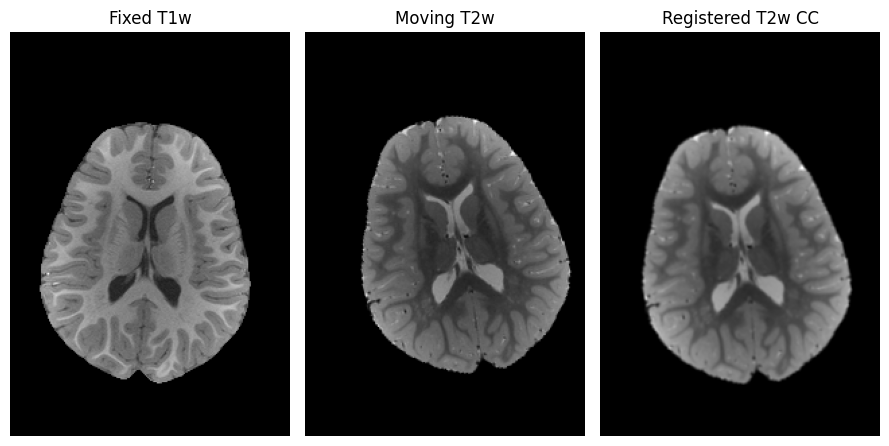

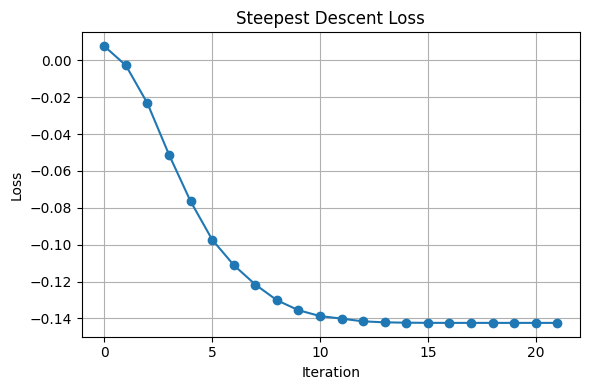

In [16]:
# test cell
fixed_image = imageNormalization(t1_coronal)
moving_image = imageNormalization(t2_transformed_coronal)
registration_mask = fixed_image > 0

registered_t2_coronal_cc, best_params, registration_history = steepest_descent_registration(
    fixed_image=fixed_image,
    moving_image=moving_image,
    mask=registration_mask,
    initial_params=(0.0, 0.0, 0.0),
    metric="CC",
    max_iter=50,
    learning_rate=100.0,
    gradient_eps=(0.5, 1.0, 1.0),
    line_search_steps=10
)

best_params_t2_cc = best_params.copy()
registration_history_t2_cc = registration_history


print("Best registration params:")
print(f"Angle: {best_params[0]:.4f} degrees")
print(f"Shift_y: {best_params[1]:.4f} pixels")
print(f"Shift_x: {best_params[2]:.4f} pixels")

show_images_L1(
    images=[fixed_image, moving_image, registered_t2_coronal_cc],
    titles=["Fixed T1w", "Moving T2w", "Registered T2w CC"]
)

loss_history = [item["loss"] for item in registration_history]
plt.figure(figsize=(6, 4))
plt.plot(loss_history, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Steepest Descent Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


### 2.3 Compare the calculated transformation parameters with the one you applied.

为了对比比较配准结果，评估哪个指标进行 SGD 得到的配准效果最好，我们可以采用多种评估方式：
- 比较逆变换参数和 SGD 计算得到参数，计算归一化后的方差，用来估计错误率
- 直接用之前用到的相似度度量指标来评估配准后的图像和原图，量化差异
- 将配准后的图像和理想原图放在同一张图中，可视化展示结果。

先分别完成能够实现以上功能的函数。

In [17]:
# functions cell
# compare the calculated transformation parameters with the applied one
def get_expected_inverse_params(applied_angle, applied_shift_y, applied_shift_x):
    """ get expected inverse transform parameters in (angle, shift_y, shift_x) order """
    return np.array([-applied_angle, -applied_shift_y, -applied_shift_x], dtype=np.float64)


def compute_transform_parameter_results(titles, estimated_params, expected_params):
    """ compute parameter error between registration results and expected inverse transform """
    expected_params = np.array(expected_params, dtype=np.float64)
    results = []

    for title, params in zip(titles, estimated_params):
        params = np.array(params, dtype=np.float64)
        error = params - expected_params
        results.append({
            "Title": title,
            "Angle": params[0],
            "Shift_y": params[1],
            "Shift_x": params[2],
            "Angle Error": error[0],
            "Shift_y Error": error[1],
            "Shift_x Error": error[2],
            "Error Norm": np.linalg.norm(error),
        })

    return results


# show the transformation parameter comparison results in a table
def print_transform_parameter_table(results, expected_params):
    """ print transformation parameter comparison table """
    print("Expected inverse transform:")
    print(f"Angle: {expected_params[0]:.4f}, Shift_y: {expected_params[1]:.4f}, Shift_x: {expected_params[2]:.4f}")
    print("=" * 118)
    print(
        f"{'Image':<24}{'Angle':>12}{'Shift_y':>12}{'Shift_x':>12}"
        f"{'Angle Err':>14}{'Shift_y Err':>14}{'Shift_x Err':>14}{'Err Norm':>14}"
    )
    print("-" * 118)
    for item in results:
        print(
            f"{item['Title']:<24}{item['Angle']:>12.4f}{item['Shift_y']:>12.4f}{item['Shift_x']:>12.4f}"
            f"{item['Angle Error']:>14.4f}{item['Shift_y Error']:>14.4f}{item['Shift_x Error']:>14.4f}"
            f"{item['Error Norm']:>14.4f}"
        )
    print("=" * 118)
    print()


# compute the similarity results between fixed image and registered moving image
def compute_similarity_results(fixed_image, registered_images, titles, metrics=("SSD", "RIU", "CC", "MI"), bins: int = 64):
    """ compute similarity metrics between fixed image and registered images """
    fixed_image = imageNormalization(fixed_image)
    results = []

    for title, registered_image in zip(titles, registered_images):
        registered_image = imageNormalization(registered_image)
        mask = (fixed_image > 0) & (registered_image > 0)
        item = {"Title": title}
        for metric in metrics:
            item[metric] = calculate_metric(fixed_image, registered_image, mask, metric=metric, bins=bins)
        results.append(item)

    return results


# show the similarity results in a table
def print_similarity_table(results, metrics=("SSD", "RIU", "CC", "MI")):
    """ print similarity metric table """
    print("Similarity between fixed image and registered image:")
    print("=" * 86)
    print(f"{'Image':<24}" + "".join([f"{metric:>14}" for metric in metrics]))
    print("-" * 86)
    for item in results:
        print(f"{item['Title']:<24}" + "".join([f"{item[metric]:>14.6f}" for metric in metrics]))
    print("=" * 86)
    print()


# compute the Degree of Overlap between fixed image and registered moving image
def compute_degree_of_overlap(fixed_image, moving_image, threshold: float = 0):
    """ compute Dice degree of overlap between two binary masks """
    fixed_mask = imageNormalization(fixed_image) > threshold
    moving_mask = imageNormalization(moving_image) > threshold
    intersection = np.sum(fixed_mask & moving_mask)
    denominator = np.sum(fixed_mask) + np.sum(moving_mask)

    if denominator == 0:
        return 0
    return 2 * intersection / denominator


def compute_overlap_results(fixed_image, registered_images, titles, threshold: float = 0):
    """ compute Degree of Overlap for all registered images """
    results = []
    for title, registered_image in zip(titles, registered_images):
        results.append({
            "Title": title,
            "Degree of Overlap": compute_degree_of_overlap(fixed_image, registered_image, threshold),
        })
    return results


# show the Degree of Overlap results in a table
def print_overlap_table(results):
    """ print Degree of Overlap table """
    print("Degree of Overlap between fixed image and registered image:")
    print("=" * 54)
    print(f"{'Image':<34}{'Degree of Overlap':>20}")
    print("-" * 54)
    for item in results:
        print(f"{item['Title']:<34}{item['Degree of Overlap']:>20.6f}")
    print("=" * 54)
    print()


# add the colored registered images to the fixed image for visualization
def create_overlay_image(fixed_image, moving_image):
    """ create colored overlay image: fixed image in green, registered image in red """
    fixed_image = imageNormalization(fixed_image)
    moving_image = imageNormalization(moving_image)

    overlay = np.zeros((*fixed_image.shape, 3), dtype=np.float64)
    overlay[..., 0] = moving_image
    overlay[..., 1] = fixed_image
    overlay[..., 2] = fixed_image
    return np.clip(overlay, 0, 1)


def show_images_L2(fixed_image, registered_images, titles, cols: int = 3):
    """ show colored overlay images """
    n = len(registered_images)
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols * 3, rows * 5))

    for i, (registered_image, title) in enumerate(zip(registered_images, titles), start=1):
        plt.subplot(rows, cols, i)
        plt.imshow(create_overlay_image(fixed_image, registered_image))
        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


#### 2.3.1 同模态参数比较

先比较同模态配准结果的参数

Expected inverse transform:
Angle: -15.0000, Shift_y: 5.0000, Shift_x: -10.0000
Image                          Angle     Shift_y     Shift_x     Angle Err   Shift_y Err   Shift_x Err      Err Norm
----------------------------------------------------------------------------------------------------------------------
Registered T1w SSD          -15.0062      2.2354    -10.9612       -0.0062       -2.7646       -0.9612        2.9270
Registered T1w RIU          -14.9979      0.5869    -10.4488        0.0021       -4.4131       -0.4488        4.4358
Registered T1w CC           -15.0300      2.2909    -10.9688       -0.0300       -2.7091       -0.9688        2.8772

Similarity between fixed image and registered image:
Image                              SSD           RIU            CC            MI
--------------------------------------------------------------------------------------
Registered T1w SSD          594.990864      0.059060      0.980081      1.731250
Registered T1w RIU          70

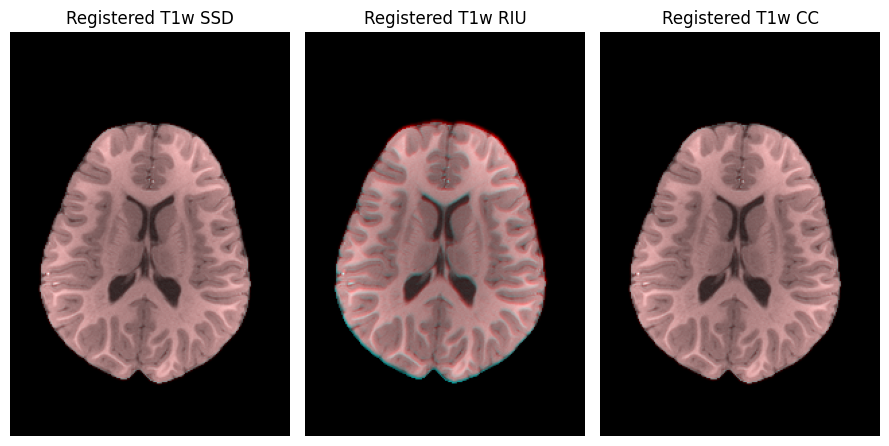

In [18]:
fixed_image_t1 = imageNormalization(t1_coronal)
registered_images_t1 = [
    registered_t1_coronal_ssd,
    registered_t1_coronal_riu,
    registered_t1_coronal_cc,
]
titles_t1 = [
    "Registered T1w SSD",
    "Registered T1w RIU",
    "Registered T1w CC",
]
estimated_params_t1 = [
    best_params_t1_ssd,
    best_params_t1_riu,
    best_params_t1_cc,
]

applied_params = np.array([rotation_angle, shift_y, shift_x], dtype=np.float64)
expected_inverse_params = get_expected_inverse_params(rotation_angle, shift_y, shift_x)

parameter_results_t1 = compute_transform_parameter_results(
    titles=titles_t1,
    estimated_params=estimated_params_t1,
    expected_params=expected_inverse_params,
)
print_transform_parameter_table(parameter_results_t1, expected_inverse_params)

similarity_results_t1 = compute_similarity_results(
    fixed_image=fixed_image_t1,
    registered_images=registered_images_t1,
    titles=titles_t1,
    metrics=("SSD", "RIU", "CC", "MI"),
)
print_similarity_table(similarity_results_t1, metrics=("SSD", "RIU", "CC", "MI"))

overlap_results_t1 = compute_overlap_results(
    fixed_image=fixed_image_t1,
    registered_images=registered_images_t1,
    titles=titles_t1,
    threshold=0,
)
print_overlap_table(overlap_results_t1)

show_images_L2(fixed_image_t1, registered_images_t1, titles_t1, cols=3)

从最后的图像来看，就能够看出配准的效果还是非常好的。量化指标也在配准后得到了显著提升。

#### 2.3.2 跨模态配准参数比较

接下来是跨模态的配准参数比较

Expected inverse transform:
Angle: -15.0000, Shift_y: 5.0000, Shift_x: -10.0000
Image                          Angle     Shift_y     Shift_x     Angle Err   Shift_y Err   Shift_x Err      Err Norm
----------------------------------------------------------------------------------------------------------------------
Registered T2w SSD           -3.8332      3.8482     -8.7977       11.1668       -1.1518        1.2023       11.2902
Registered T2w RIU          -14.5642      2.2864    -11.3056        0.4358       -2.7136       -1.3056        3.0427
Registered T2w CC            -4.1486      6.6409     -8.4145       10.8514        1.6409        1.5855       11.0887

Similarity between fixed image and registered image:
Image                              SSD           RIU            CC            MI
--------------------------------------------------------------------------------------
Registered T2w SSD          370.861538    103.756592      0.407670      0.341805
Registered T2w RIU           8

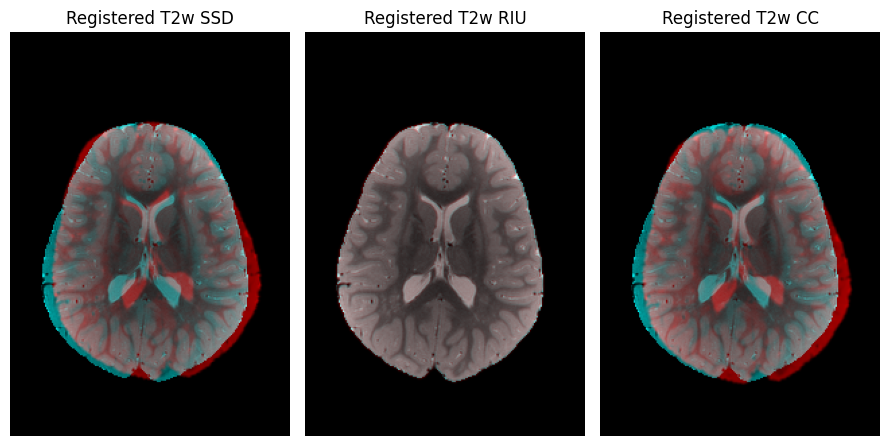

In [19]:
# test cell: T2w
fixed_image_t2 = imageNormalization(t2_coronal)
registered_images_t2 = [
    registered_t2_coronal_ssd,
    registered_t2_coronal_riu,
    registered_t2_coronal_cc,
]
titles_t2 = [
    "Registered T2w SSD",
    "Registered T2w RIU",
    "Registered T2w CC",
]
estimated_params_t2 = [
    best_params_t2_ssd,
    best_params_t2_riu,
    best_params_t2_cc,
]

applied_params = np.array([rotation_angle, shift_y, shift_x], dtype=np.float64)
expected_inverse_params = get_expected_inverse_params(rotation_angle, shift_y, shift_x)

parameter_results_t2 = compute_transform_parameter_results(
    titles=titles_t2,
    estimated_params=estimated_params_t2,
    expected_params=expected_inverse_params,
)
print_transform_parameter_table(parameter_results_t2, expected_inverse_params)

similarity_results_t2 = compute_similarity_results(
    fixed_image=fixed_image_t2,
    registered_images=registered_images_t2,
    titles=titles_t2,
    metrics=("SSD", "RIU", "CC", "MI"),
)
print_similarity_table(similarity_results_t2, metrics=("SSD", "RIU", "CC", "MI"))

overlap_results_t2 = compute_overlap_results(
    fixed_image=fixed_image_t2,
    registered_images=registered_images_t2,
    titles=titles_t2,
    threshold=0,
)
print_overlap_table(overlap_results_t2)

show_images_L2(fixed_image_t2, registered_images_t2, titles_t2, cols=3)

从最后的掩膜图可以看出来：跨模态配准中 `RIU` 作为指标的 SGD 效果会好很多。另外两个指标由于是对像素的强度判断，在跨模态的配准中容易出现错误。

**另外，这一部分我们不会用互信息（MI）来进行 SGD，因为 MI 的空间中有很多的 Impulse。SGD 的原理是利用求导 / 微分，获取当前位置的梯度，通过梯度确认优化的方向。但是 MI 空间中的 Impulse 在数学上都是不可导的，这就导致 SGD 的方法在 MI 空间中失效了。**

### 2.4 Try your best to improve the registration effect by using any scientific method

在以上部分的实验中，我发现了以下可以优化的地方：

1. 初始点选不好容易陷入局部最小值

RIU 这个指标有很多局部最小值，初始点选得不好，优化结果就会卡在局部最优，找不到真正的对齐位置。为了解决这个问题，我采用了多分辨率配准：先把图像缩小，在低分辨率下跑一遍优化，得到一个大致方向，再用这个结果作为高分辨率优化的起点。这样相当于先看全局再抠细节，不容易跑偏。

但是实际运行过程中这个方法的配准结果并不是很好，因此我转换思路。将图像的有效区域先跑一边配准，将轮廓的配准信息作为初始坐标进行配准，这样就能提高 RIU 的命中率。

2. 学习率不够灵活

如果学习率固定，刚开始可能太慢，后面可能又跳过头。改进方法是：刚开始用大学习率快速下降，等到损失曲线平缓了，自动减小学习率进行微调。这样既保证了速度，又保证了精度。

3. 同模态和跨模态应该用不同的指标

同模态下图像强度关系是线性的，用SSD（误差平方和）效果就很好；跨模态下强度关系复杂，更适合用RIU。所以加一个参数来区分模式，自动选择用哪个指标。

综合以上三点，改进后的配准流程是：先根据模式选指标（SSD或RIU），然后用轮廓信息配准得到粗调后的初始坐标，同时在优化过程中动态调整学习率。

In [23]:
# function cell
from scipy.ndimage import zoom


def choose_improved_metric(modality="intra"):
    """ choose optimization metric according to modality type """
    modality = modality.lower()
    if modality == "intra":
        return "SSD"
    if modality == "inter":
        return "RIU"
    raise ValueError("modality should be 'intra' or 'inter'")


def improved_calculate_loss(fixed_image, moving_image, mask, metric="SSD", bins: int = 64):
    """ calculate loss for improved registration """
    metric = metric.upper()
    metric_value = calculate_metric(fixed_image, moving_image, mask, metric=metric, bins=bins)

    if metric == "SSD":
        valid_count = np.sum(mask)
        if valid_count == 0:
            return np.inf
        return metric_value / valid_count
    if metric == "RIU":
        return metric_value
    return -metric_value


def improved_calculate_gradient(
    fixed_image,
    moving_image,
    mask,
    params,
    metric="SSD",
    bins: int = 64,
    eps=(0.5, 1.0, 1.0),
):
    """ calculate numerical gradient for improved registration """
    params = np.array(params, dtype=np.float64)
    gradient = np.zeros_like(params)

    for i, step in enumerate(eps):
        params_plus = params.copy()
        params_minus = params.copy()
        params_plus[i] += step
        params_minus[i] -= step

        image_plus = apply_registration_transform(moving_image, params_plus)
        image_minus = apply_registration_transform(moving_image, params_minus)
        loss_plus = improved_calculate_loss(fixed_image, image_plus, mask, metric, bins)
        loss_minus = improved_calculate_loss(fixed_image, image_minus, mask, metric, bins)
        gradient[i] = (loss_plus - loss_minus) / (2 * step)

        if not np.isfinite(gradient[i]):
            gradient[i] = 0

    return gradient


def improved_steepest_descent_registration(
    fixed_image,
    moving_image,
    mask,
    initial_params=(0.0, 0.0, 0.0),
    metric="SSD",
    learning_rates=(100.0, 20.0, 5.0),
    max_iters=(30, 30, 30),
    gradient_eps=(0.5, 1.0, 1.0),
    line_search_steps: int = 20,
    tolerance: float = 1e-6,
    bins: int = 64,
    reference_params=None,
    param_delta_limit=None,
    max_update=None,
):
    """ steepest descent with staged learning rates """
    fixed_image = imageNormalization(fixed_image)
    moving_image = imageNormalization(moving_image)
    params = np.array(initial_params, dtype=np.float64)
    history = []

    if reference_params is None:
        reference_params = params.copy()
    else:
        reference_params = np.array(reference_params, dtype=np.float64)

    if param_delta_limit is not None:
        param_delta_limit = np.array(param_delta_limit, dtype=np.float64)

    if max_update is not None:
        max_update = np.array(max_update, dtype=np.float64)

    print(f"Use improved metric: {metric.upper()}")
    print(f"{'Stage':<7}{'Iter':<6}{'Loss':>14}{'Metric':>14}{'Angle':>12}{'Shift_y':>12}{'Shift_x':>12}{'Grad norm':>14}{'LR':>10}")
    print("-" * 104)

    global_iter = 0
    for stage_idx, (learning_rate, max_iter) in enumerate(zip(learning_rates, max_iters), start=1):
        for iteration in range(max_iter):
            transformed_image = apply_registration_transform(moving_image, params)
            current_loss = improved_calculate_loss(fixed_image, transformed_image, mask, metric, bins)
            current_metric = calculate_metric(fixed_image, transformed_image, mask, metric=metric, bins=bins)
            gradient = improved_calculate_gradient(
                fixed_image,
                moving_image,
                mask,
                params,
                metric=metric,
                bins=bins,
                eps=gradient_eps,
            )
            grad_norm = np.linalg.norm(gradient)

            history.append({
                "iter": global_iter,
                "stage": stage_idx,
                "loss": current_loss,
                "metric": current_metric,
                "params": params.copy(),
                "gradient": gradient.copy(),
                "learning_rate": learning_rate,
            })

            if global_iter % 5 == 0:
                print(
                    f"{stage_idx:<7}{global_iter:<6}{current_loss:>14.6f}{current_metric:>14.6f}"
                    f"{params[0]:>12.4f}{params[1]:>12.4f}{params[2]:>12.4f}{grad_norm:>14.6f}{learning_rate:>10.4f}"
                )

            if not np.isfinite(current_loss) or grad_norm < tolerance:
                return apply_registration_transform(moving_image, params), params, history

            step_size = learning_rate
            updated = False
            for _ in range(line_search_steps):
                best_candidate_loss = current_loss
                best_candidate_params = params.copy()

                for direction in (-1, 1):
                    update = direction * step_size * gradient
                    if max_update is not None:
                        update = np.clip(update, -max_update, max_update)

                    candidate_params = params + update
                    if param_delta_limit is not None:
                        candidate_params = np.clip(
                            candidate_params,
                            reference_params - param_delta_limit,
                            reference_params + param_delta_limit,
                        )

                    candidate_image = apply_registration_transform(moving_image, candidate_params)
                    candidate_loss = improved_calculate_loss(fixed_image, candidate_image, mask, metric, bins)

                    if candidate_loss < best_candidate_loss:
                        best_candidate_loss = candidate_loss
                        best_candidate_params = candidate_params

                if best_candidate_loss < current_loss:
                    params = best_candidate_params
                    updated = True
                    break

                step_size *= 0.5

            global_iter += 1
            if not updated:
                break

    registered_image = apply_registration_transform(moving_image, params)
    return registered_image, params, history


def resize_params_to_full_resolution(params, scale):
    """ convert low-resolution params to full-resolution params """
    params = np.array(params, dtype=np.float64)
    return np.array([params[0], params[1] / scale, params[2] / scale], dtype=np.float64)


def improved_multires_registration(
    fixed_image,
    moving_image,
    modality="intra",
    low_resolution_scale: float = 0.5,
    coarse_learning_rates=None,
    fine_learning_rates=None,
):
    """ multi-resolution registration with modality-aware metric and staged learning rates """
    metric = choose_improved_metric(modality)
    fixed_image = imageNormalization(fixed_image)
    moving_image = imageNormalization(moving_image)

    fixed_low = zoom(fixed_image, low_resolution_scale, order=1)
    moving_low = zoom(moving_image, low_resolution_scale, order=1)
    low_mask = fixed_low > 0
    full_mask = fixed_image > 0

    if metric == "SSD":
        if coarse_learning_rates is None:
            coarse_learning_rates = (100.0, 50.0, 10.0)
        if fine_learning_rates is None:
            fine_learning_rates = (200.0, 80.0, 20.0, 5.0)
        gradient_eps = (0.5, 1.0, 1.0)
    else:
        if coarse_learning_rates is None:
            coarse_learning_rates = (10.0, 2.0, 0.5)
        if fine_learning_rates is None:
            fine_learning_rates = (10.0, 2.0, 0.5, 0.1)
        gradient_eps = (0.2, 0.5, 0.5)

    print("Low-resolution coarse registration")
    coarse_registered, coarse_params, coarse_history = improved_steepest_descent_registration(
        fixed_image=fixed_low,
        moving_image=moving_low,
        mask=low_mask,
        initial_params=(0.0, 0.0, 0.0),
        metric=metric,
        learning_rates=coarse_learning_rates,
        max_iters=tuple([20] * len(coarse_learning_rates)),
        gradient_eps=gradient_eps,
        line_search_steps=20,
    )

    fine_initial_params = resize_params_to_full_resolution(coarse_params, low_resolution_scale)
    print("Parameter mapping from low-resolution to full-resolution")
    print(f"Scale: {low_resolution_scale:.4f}")
    print(f"Coarse params: angle={coarse_params[0]:.4f}, shift_y={coarse_params[1]:.4f}, shift_x={coarse_params[2]:.4f}")
    print(f"Mapped params: angle={fine_initial_params[0]:.4f}, shift_y={fine_initial_params[1]:.4f}, shift_x={fine_initial_params[2]:.4f}")
    print("Full-resolution fine registration")
    fine_registered, fine_params, fine_history = improved_steepest_descent_registration(
        fixed_image=fixed_image,
        moving_image=moving_image,
        mask=full_mask,
        initial_params=fine_initial_params,
        metric=metric,
        learning_rates=fine_learning_rates,
        max_iters=tuple([30] * len(fine_learning_rates)),
        gradient_eps=gradient_eps,
        line_search_steps=30,
    )

    return fine_registered, fine_params, {
        "metric": metric,
        "coarse_params": coarse_params,
        "fine_initial_params": fine_initial_params,
        "coarse_history": coarse_history,
        "fine_history": fine_history,
    }


def make_positive_mask_image(image, threshold: float = 0):
    """ convert image > threshold area to a binary mask image """
    normalized_image = imageNormalization(image)
    return (normalized_image > threshold).astype(np.float64)


def improved_mask_initialized_registration(
    fixed_image,
    moving_image,
    modality="inter",
    mask_threshold: float = 0,
    mask_learning_rates=(80.0, 30.0, 10.0, 2.0),
    fine_learning_rates=None,
):
    """ use image > 0 masks for coarse initialization, then refine by modality-aware metric """
    metric = choose_improved_metric(modality)
    fixed_image = imageNormalization(fixed_image)
    moving_image = imageNormalization(moving_image)

    fixed_mask_image = make_positive_mask_image(fixed_image, threshold=mask_threshold)
    moving_mask_image = make_positive_mask_image(moving_image, threshold=mask_threshold)
    coarse_mask = (fixed_mask_image > 0) | (moving_mask_image > 0)
    full_mask = fixed_image > 0

    if fine_learning_rates is None:
        fine_learning_rates = (0.5, 0.1, 0.02) if metric == "RIU" else (200.0, 80.0, 20.0, 5.0)

    if metric == "RIU":
        fine_gradient_eps = (0.05, 0.2, 0.2)
        fine_max_update = (0.2, 0.5, 0.5)
        fine_param_delta_limit = (6.0, 10.0, 10.0)
    else:
        fine_gradient_eps = (0.5, 1.0, 1.0)
        fine_max_update = None
        fine_param_delta_limit = None

    print("Positive-mask coarse registration")
    mask_registered, mask_params, mask_history = improved_steepest_descent_registration(
        fixed_image=fixed_mask_image,
        moving_image=moving_mask_image,
        mask=coarse_mask,
        initial_params=(0.0, 0.0, 0.0),
        metric="SSD",
        learning_rates=mask_learning_rates,
        max_iters=tuple([25] * len(mask_learning_rates)),
        gradient_eps=(0.5, 1.0, 1.0),
        line_search_steps=30,
    )

    print("Full-image fine registration")
    print(">>> initial params: angle={:.4f}, shift_y={:.4f}, shift_x={:.4f}".format(*mask_params))
    if metric == "RIU":
        print(">>> RIU fine registration uses small steps and parameter bounds around the mask result")
    fine_registered, fine_params, fine_history = improved_steepest_descent_registration(
        fixed_image=fixed_image,
        moving_image=moving_image,
        mask=full_mask,
        initial_params=mask_params,
        metric=metric,
        learning_rates=fine_learning_rates,
        max_iters=tuple([30] * len(fine_learning_rates)),
        gradient_eps=fine_gradient_eps,
        line_search_steps=30,
        reference_params=mask_params,
        param_delta_limit=fine_param_delta_limit,
        max_update=fine_max_update,
    )

    return fine_registered, fine_params, {
        "metric": metric,
        "mask_params": mask_params,
        "mask_history": mask_history,
        "fine_history": fine_history,
        "fixed_mask_image": fixed_mask_image,
        "moving_mask_image": moving_mask_image,
        "mask_registered": mask_registered,
    }


# keep the previous function name usable, but it now uses the whole positive mask instead of only edges
def improved_edge_initialized_registration(
    fixed_image,
    moving_image,
    modality="inter",
    edge_threshold: float = 0,
    edge_learning_rates=(80.0, 30.0, 10.0, 2.0),
    fine_learning_rates=None,
):
    return improved_mask_initialized_registration(
        fixed_image=fixed_image,
        moving_image=moving_image,
        modality=modality,
        mask_threshold=edge_threshold,
        mask_learning_rates=edge_learning_rates,
        fine_learning_rates=fine_learning_rates,
    )


#### 2.4.1 Intra-modality: T1w & T1w

Low-resolution coarse registration
Use improved metric: SSD
Stage  Iter            Loss        Metric       Angle     Shift_y     Shift_x     Grad norm        LR
--------------------------------------------------------------------------------------------------------
1      0           0.073691    434.336330      0.0000      0.0000      0.0000      0.005901  100.0000
1      5           0.054063    318.646968     -0.8718      1.5767     -2.2214      0.004989  100.0000
1      10          0.045337    267.214499     -1.6680      2.3084     -4.0945      0.003531  100.0000
1      15          0.039172    230.879207     -2.6115      2.4871     -5.4180      0.003037  100.0000
2      20          0.034717    204.624511     -3.6609      2.2418     -6.4929      0.003041   50.0000
2      25          0.034005    200.424411     -4.0851      2.0649     -6.8060      0.002777   50.0000
2      30          0.034005    200.424407     -4.0854      2.0648     -6.8062      0.002776   50.0000
Parameter mapping f

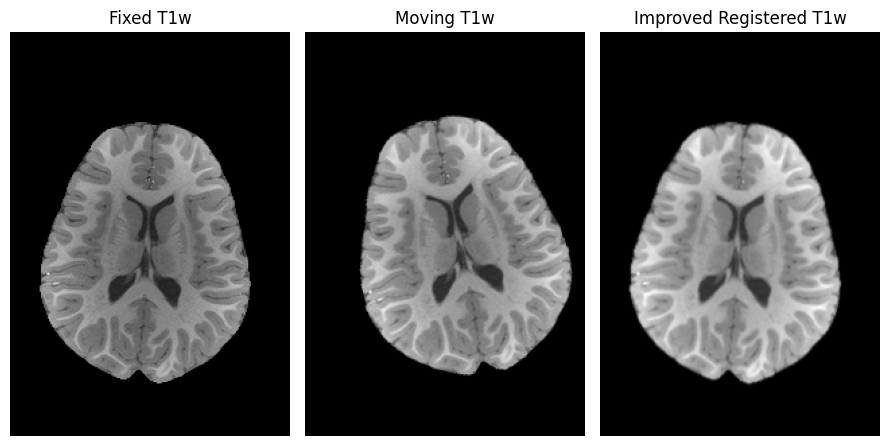

Similarity between fixed image and registered image:
Image                              SSD           RIU            CC            MI
--------------------------------------------------------------------------------------
Moving T1w Before Registration    576.766912      8.568802      0.309234      0.154634
Original SGD Registered T1w (SSD)    594.990864      0.059060      0.980081      1.731250
Improved Registered T1w     589.891819      0.060628      0.979147      1.701307

Degree of Overlap between fixed image and registered image:
Image                                Degree of Overlap
------------------------------------------------------
Moving T1w Before Registration                0.880257
Original SGD Registered T1w (SSD)             0.975905
Improved Registered T1w                       0.975926



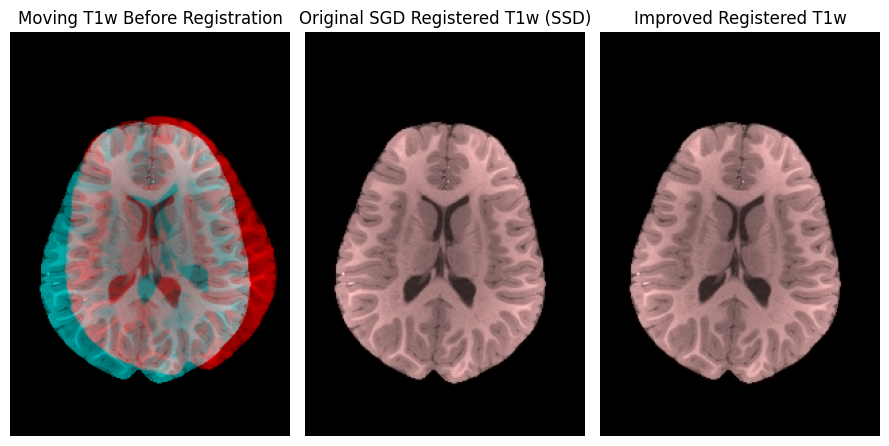

In [24]:
# test cell
# Improved registration: modality-aware metric + multi-resolution + staged learning rate
fixed_image_improved = imageNormalization(t1_coronal)

registered_t1_coronal_improved, best_params_t1_improved, improved_history_t1 = improved_multires_registration(
    fixed_image=fixed_image_improved,
    moving_image=t1_transformed_coronal,
    modality="intra",
    low_resolution_scale=0.5,
)

print("Improved registration params:")
print("=" * 60)
print(f"T1w improved ({improved_history_t1['metric']}): angle={best_params_t1_improved[0]:.4f}, shift_y={best_params_t1_improved[1]:.4f}, shift_x={best_params_t1_improved[2]:.4f}")
print("=" * 60)

show_images_L1(
    images=[fixed_image_improved, imageNormalization(t1_transformed_coronal), registered_t1_coronal_improved],
    titles=["Fixed T1w", "Moving T1w", "Improved Registered T1w"],
)

# show Similarity metrics to evaluate the registration results
improved_comparison_images_t1 = [
    imageNormalization(t1_transformed_coronal),
    registered_t1_coronal_ssd,
    registered_t1_coronal_improved,
]
improved_comparison_titles_t1 = [
    "Moving T1w Before Registration",
    "Original SGD Registered T1w (SSD)",
    "Improved Registered T1w",
]

improved_similarity_results = compute_similarity_results(
    fixed_image=fixed_image_improved,
    registered_images=improved_comparison_images_t1,
    titles=improved_comparison_titles_t1,
    metrics=("SSD", "RIU", "CC", "MI"),
)
print_similarity_table(improved_similarity_results, metrics=("SSD", "RIU", "CC", "MI"))

improved_overlap_results = compute_overlap_results(
    fixed_image=fixed_image_improved,
    registered_images=improved_comparison_images_t1,
    titles=improved_comparison_titles_t1,
    threshold=0,
)
print_overlap_table(improved_overlap_results)

show_images_L2(
    fixed_image_improved,
    improved_comparison_images_t1,
    improved_comparison_titles_t1,
    cols=3,
)


#### 2.4.2 Inter-modality: T1w & T2w

Positive-mask coarse registration
Use improved metric: SSD
Stage  Iter            Loss        Metric       Angle     Shift_y     Shift_x     Grad norm        LR
--------------------------------------------------------------------------------------------------------
1      0           0.214929   5563.000000      0.0000      0.0000      0.0000      0.010633   80.0000
1      5           0.130307   3372.738012     -1.5204      2.1963     -4.7128      0.013276   80.0000
1      10          0.077744   2012.247721     -3.2432      3.4712     -8.7998      0.009418   80.0000
1      15          0.047191   1221.437138     -5.2204      3.8213    -11.6940      0.007910   80.0000
1      20          0.029306    758.523553     -7.0571      3.9610    -13.6809      0.004505   80.0000
2      25          0.025409    657.658059     -8.3517      4.0697    -13.9563      0.002479   30.0000
2      30          0.024186    626.006752     -8.6925      4.0424    -13.8126      0.002460   30.0000
2      35          0

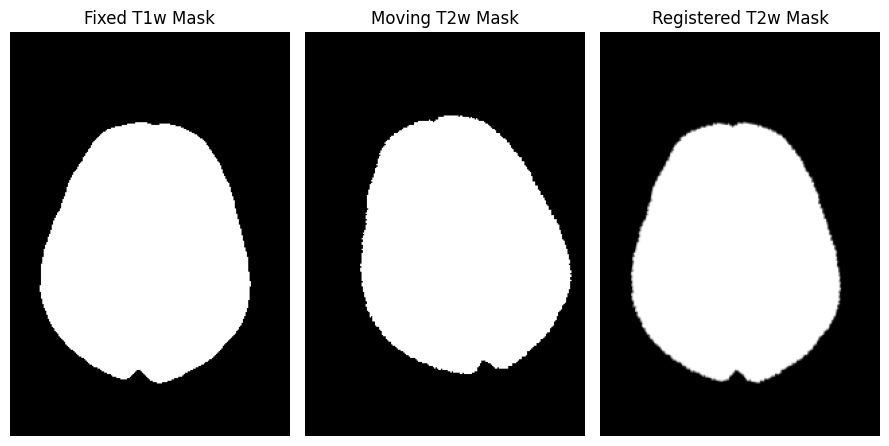

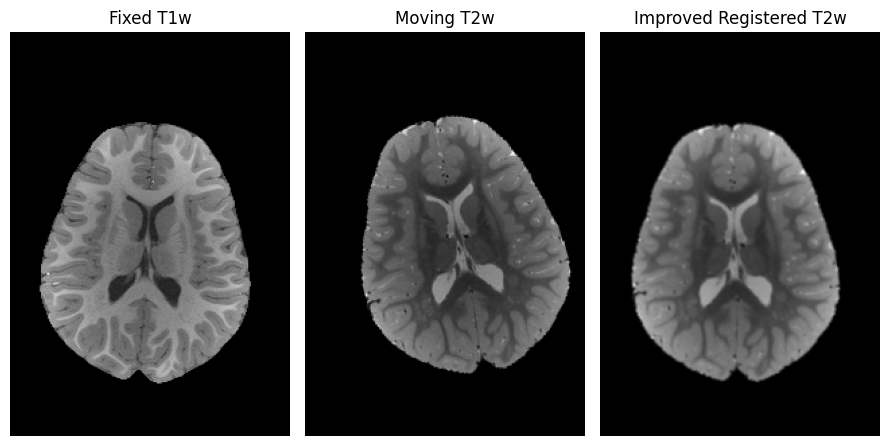

Similarity between fixed image and registered image:
Image                              SSD           RIU            CC            MI
--------------------------------------------------------------------------------------
Moving T2w Before Registration    735.167820      2.880618      0.168162      0.117990
Original SGD Registered T2w (RIU)    832.970385      4.421900     -0.041096      0.324226
Improved Registered T2w     724.587444    107.465628      0.117257      0.221699

Degree of Overlap between fixed image and registered image:
Image                                Degree of Overlap
------------------------------------------------------
Moving T2w Before Registration                0.879597
Original SGD Registered T2w (RIU)             0.987574
Improved Registered T2w                       0.976967



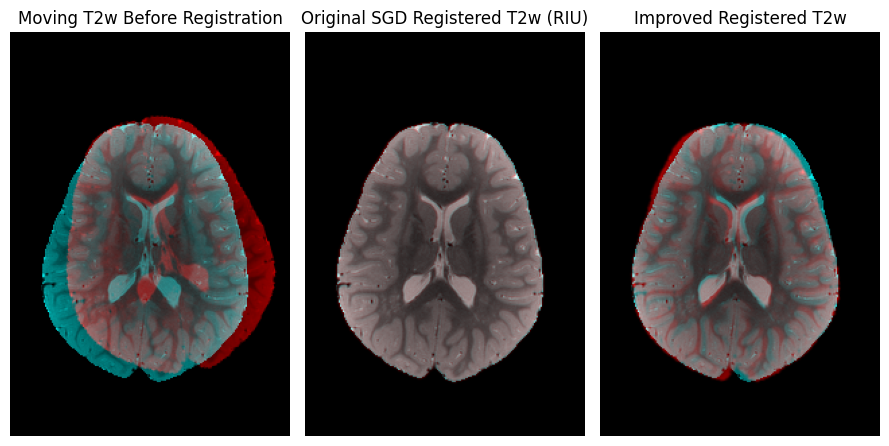

In [25]:
# test cell
# Improved registration: positive-mask initialization + RIU fine registration for inter-modality
fixed_image_improved = imageNormalization(t1_coronal)
fixed_image_t2 = imageNormalization(t2_coronal)

registered_t2_coronal_improved, best_params_t2_improved, improved_history_t2 = improved_mask_initialized_registration(
    fixed_image=fixed_image_improved,
    moving_image=t2_transformed_coronal,
    modality="inter",
    mask_threshold=0,
)

print("Improved registration params:")
print("=" * 60)
print(f"T2w improved ({improved_history_t2['metric']}): angle={best_params_t2_improved[0]:.4f}, shift_y={best_params_t2_improved[1]:.4f}, shift_x={best_params_t2_improved[2]:.4f}")
print(f"Mask initial params: angle={improved_history_t2['mask_params'][0]:.4f}, shift_y={improved_history_t2['mask_params'][1]:.4f}, shift_x={improved_history_t2['mask_params'][2]:.4f}")
print("=" * 60)

show_images_L1(
    images=[
        improved_history_t2["fixed_mask_image"],
        improved_history_t2["moving_mask_image"],
        improved_history_t2["mask_registered"],
    ],
    titles=["Fixed T1w Mask", "Moving T2w Mask", "Registered T2w Mask"],
)

show_images_L1(
    images=[fixed_image_improved, imageNormalization(t2_transformed_coronal), registered_t2_coronal_improved],
    titles=["Fixed T1w", "Moving T2w", "Improved Registered T2w"],
)

# show Similarity metrics to evaluate the registration results
improved_comparison_images_t2 = [
    imageNormalization(t2_transformed_coronal),
    registered_t2_coronal_riu,
    registered_t2_coronal_improved,
]
improved_comparison_titles_t2 = [
    "Moving T2w Before Registration",
    "Original SGD Registered T2w (RIU)",
    "Improved Registered T2w",
]

improved_similarity_results = compute_similarity_results(
    fixed_image=fixed_image_improved,
    registered_images=improved_comparison_images_t2,
    titles=improved_comparison_titles_t2,
    metrics=("SSD", "RIU", "CC", "MI"),
)
print_similarity_table(improved_similarity_results, metrics=("SSD", "RIU", "CC", "MI"))

improved_overlap_results = compute_overlap_results(
    fixed_image=fixed_image_improved,
    registered_images=improved_comparison_images_t2,
    titles=improved_comparison_titles_t2,
    threshold=0,
)
print_overlap_table(improved_overlap_results)

show_images_L2(
    fixed_image_t2,
    improved_comparison_images_t2,
    improved_comparison_titles_t2,
    cols=3,
)


虽然跨模态的配准结果没有之前调参的结果好，但是由于完全不需要调参的过程，并且配准后的各项指标都得到了明显的提升。因此感觉还是不错的。

## Project 3 Tool-based Co-registration


### 3.1 Use standard toolkits (SimpleITK) to complete the Project2 tasks

#### 3.1.1 Inter-modality

SimpleITK Inter-modality Registration (T2w to T1w):
Angle:  -5.1965 degrees
Shift_y: -5.9271 pixels
Shift_x: 14.3810 pixels
Iterations: 200
Initial metric: -0.411346
Final metric:   -0.620731

Applied transform parameters:
Angle: 15.0000 degrees, Shift_y: -5.0000, Shift_x: 10.0000

SimpleITK Inter-modality Registration (T2w to T1w) similarity:
SSD         714.991781
RIU          16.675474
CC            0.195808
MI            0.184679



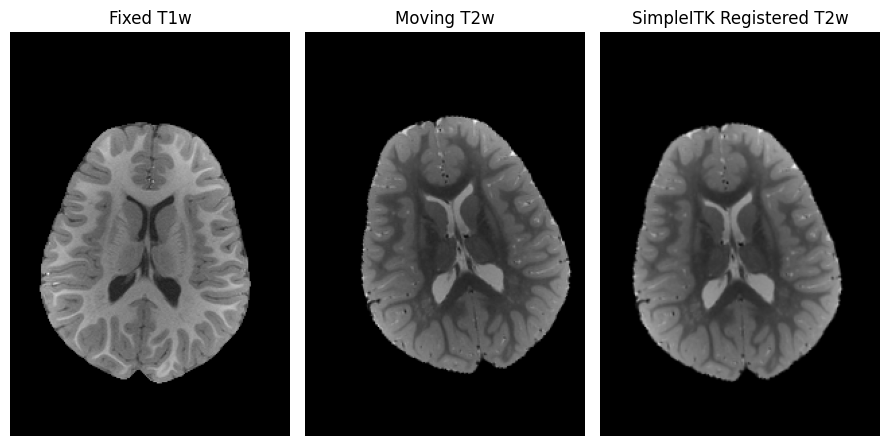

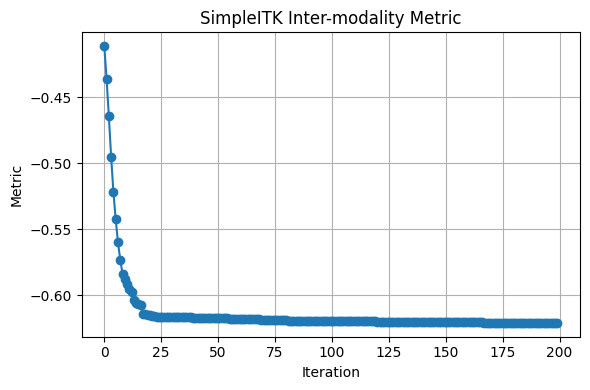

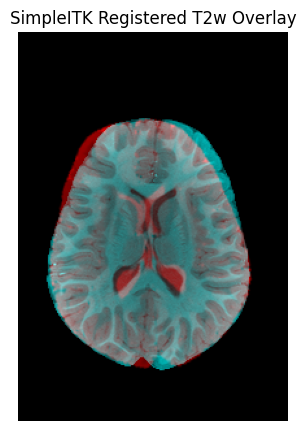

In [26]:
# function cell: SimpleITK inter-modality registration
import SimpleITK as sitk


def numpy_to_sitk_image(image):
    """ convert 2D numpy image to SimpleITK image """
    image = imageNormalization(image).astype(np.float32)
    sitk_image = sitk.GetImageFromArray(image)
    sitk_image.SetSpacing((1.0, 1.0))
    sitk_image.SetOrigin((0.0, 0.0))
    return sitk_image


def sitk_image_to_numpy(sitk_image):
    """ convert SimpleITK image to numpy image """
    return sitk.GetArrayFromImage(sitk_image)


def get_sitk_metric_values(registration_method):
    """ record metric values during SimpleITK optimization """
    metric_values = []

    def command_iteration():
        metric_values.append(registration_method.GetMetricValue())

    registration_method.AddCommand(sitk.sitkIterationEvent, command_iteration)
    return metric_values


def simpleitk_register_2d(
    fixed_image,
    moving_image,
    metric="MI",
    learning_rate: float = 2.0,
    min_step: float = 1e-4,
    max_iter: int = 200,
    bins: int = 50,
):
    """ register 2D image using SimpleITK Euler2DTransform """
    fixed_sitk = numpy_to_sitk_image(fixed_image)
    moving_sitk = numpy_to_sitk_image(moving_image)

    initial_transform = sitk.CenteredTransformInitializer(
        fixed_sitk,
        moving_sitk,
        sitk.Euler2DTransform(),
        sitk.CenteredTransformInitializerFilter.GEOMETRY,
    )

    registration_method = sitk.ImageRegistrationMethod()
    metric = metric.upper()
    if metric == "MI":
        registration_method.SetMetricAsMattesMutualInformation(numberOfHistogramBins=bins)
    elif metric == "MS" or metric == "SSD":
        registration_method.SetMetricAsMeanSquares()
    elif metric == "CC":
        registration_method.SetMetricAsCorrelation()
    else:
        raise ValueError("metric should be one of: MI, MS, SSD, CC")

    registration_method.SetInterpolator(sitk.sitkLinear)
    registration_method.SetOptimizerAsRegularStepGradientDescent(
        learningRate=learning_rate,
        minStep=min_step,
        numberOfIterations=max_iter,
        relaxationFactor=0.5,
        gradientMagnitudeTolerance=1e-8,
    )
    registration_method.SetOptimizerScalesFromPhysicalShift()
    registration_method.SetInitialTransform(initial_transform, inPlace=False)

    metric_values = get_sitk_metric_values(registration_method)
    final_transform = registration_method.Execute(fixed_sitk, moving_sitk)

    registered_sitk = sitk.Resample(
        moving_sitk,
        fixed_sitk,
        final_transform,
        sitk.sitkLinear,
        0.0,
        moving_sitk.GetPixelID(),
    )
    registered_image = sitk_image_to_numpy(registered_sitk)

    return registered_image, final_transform, metric_values


def get_simpleitk_transform_params(transform):
    """ get angle and translation from SimpleITK Euler2DTransform """
    params = transform.GetParameters()
    angle = np.rad2deg(params[0])
    shift_x = params[1]
    shift_y = params[2]
    return np.array([angle, shift_y, shift_x], dtype=np.float64)


def print_simpleitk_registration_result(title, transform, metric_values):
    """ print SimpleITK registration parameters and optimizer information """
    params = get_simpleitk_transform_params(transform)
    print(f"{title}:")
    print("=" * 60)
    print(f"Angle:  {params[0]:.4f} degrees")
    print(f"Shift_y: {params[1]:.4f} pixels")
    print(f"Shift_x: {params[2]:.4f} pixels")
    print(f"Iterations: {len(metric_values)}")
    if len(metric_values) > 0:
        print(f"Initial metric: {metric_values[0]:.6f}")
        print(f"Final metric:   {metric_values[-1]:.6f}")
    print("=" * 60)
    print()
    return params


def print_simpleitk_similarity(title, fixed_image, registered_image):
    """ print similarity metrics after SimpleITK registration """
    fixed_norm = imageNormalization(fixed_image)
    registered_norm = imageNormalization(registered_image)
    mask = (fixed_norm > 0) & (registered_norm > 0)
    print(f"{title} similarity:")
    print("=" * 50)
    for metric in ["SSD", "RIU", "CC", "MI"]:
        value = calculate_metric(fixed_norm, registered_norm, mask, metric=metric)
        print(f"{metric:<8}{value:>14.6f}")
    print("=" * 50)
    print()


def plot_simpleitk_metric(metric_values, title):
    """ plot SimpleITK optimizer metric curve """
    plt.figure(figsize=(6, 4))
    plt.plot(metric_values, marker="o")
    plt.xlabel("Iteration")
    plt.ylabel("Metric")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Inter-modality: register transformed T2w slice back to fixed T1w slice
fixed_image_sitk_inter = imageNormalization(t1_coronal)
moving_image_sitk_inter = imageNormalization(t2_transformed_coronal)

registered_t2_coronal_sitk, sitk_t2_transform, sitk_t2_metric_values = simpleitk_register_2d(
    fixed_image=fixed_image_sitk_inter,
    moving_image=moving_image_sitk_inter,
    metric="MI",
    learning_rate=2.0,
    min_step=1e-4,
    max_iter=200,
    bins=50,
)

sitk_t2_params = print_simpleitk_registration_result(
    "SimpleITK Inter-modality Registration (T2w to T1w)",
    sitk_t2_transform,
    sitk_t2_metric_values,
)
print("Applied transform parameters:")
print(f"Angle: {rotation_angle:.4f} degrees, Shift_y: {shift_y:.4f}, Shift_x: {shift_x:.4f}")
print()

print_simpleitk_similarity(
    "SimpleITK Inter-modality Registration (T2w to T1w)",
    fixed_image_sitk_inter,
    registered_t2_coronal_sitk,
)

show_images_L1(
    images=[fixed_image_sitk_inter, moving_image_sitk_inter, registered_t2_coronal_sitk],
    titles=["Fixed T1w", "Moving T2w", "SimpleITK Registered T2w"],
)
plot_simpleitk_metric(sitk_t2_metric_values, "SimpleITK Inter-modality Metric")

show_images_L2(
    fixed_image_sitk_inter,
    [registered_t2_coronal_sitk],
    ["SimpleITK Registered T2w Overlay"],
    cols=1
)

不知道为啥，感觉配准结果不如我自己调参后的结果。

#### 3.1.2 Intra-modality

SimpleITK Intra-modality Registration (T1w to T1w):
Angle:  -14.9991 degrees
Shift_y: -5.0003 pixels
Shift_x: 10.0011 pixels
Iterations: 68
Initial metric: 0.038087
Final metric:   0.003618

Applied transform parameters:
Angle: 15.0000 degrees, Shift_y: -5.0000, Shift_x: 10.0000

SimpleITK Intra-modality Registration (T1w to T1w) similarity:
SSD         271.237744
RIU           0.050683
CC            0.985446
MI            1.879839



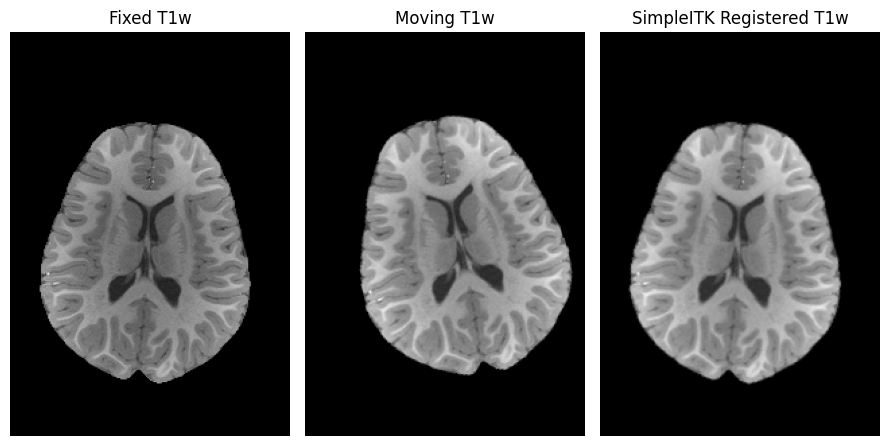

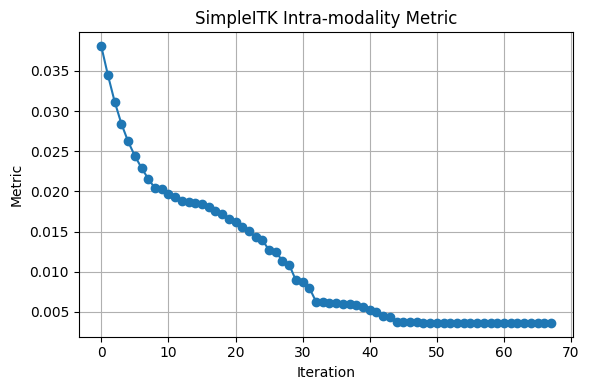

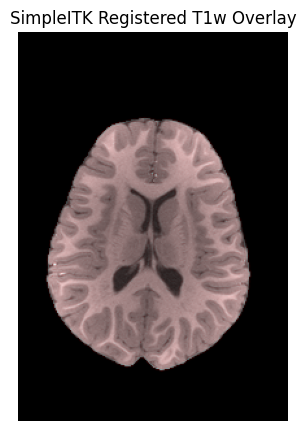

In [27]:
# function cell: SimpleITK intra-modality registration
# Intra-modality: register transformed T1w slice back to fixed T1w slice

fixed_image_sitk_intra = imageNormalization(t1_coronal)
moving_image_sitk_intra = imageNormalization(t1_transformed_coronal)

registered_t1_coronal_sitk, sitk_t1_transform, sitk_t1_metric_values = simpleitk_register_2d(
    fixed_image=fixed_image_sitk_intra,
    moving_image=moving_image_sitk_intra,
    metric="SSD",
    learning_rate=2.0,
    min_step=1e-4,
    max_iter=200,
)

sitk_t1_params = print_simpleitk_registration_result(
    "SimpleITK Intra-modality Registration (T1w to T1w)",
    sitk_t1_transform,
    sitk_t1_metric_values,
)
print("Applied transform parameters:")
print(f"Angle: {rotation_angle:.4f} degrees, Shift_y: {shift_y:.4f}, Shift_x: {shift_x:.4f}")
print()

print_simpleitk_similarity(
    "SimpleITK Intra-modality Registration (T1w to T1w)",
    fixed_image_sitk_intra,
    registered_t1_coronal_sitk,
)

show_images_L1(
    images=[fixed_image_sitk_intra, moving_image_sitk_intra, registered_t1_coronal_sitk],
    titles=["Fixed T1w", "Moving T1w", "SimpleITK Registered T1w"],
)
plot_simpleitk_metric(sitk_t1_metric_values, "SimpleITK Intra-modality Metric")

show_images_L2(
    fixed_image_sitk_intra,
    [registered_t1_coronal_sitk],
    ["SimpleITK Registered T1w Overlay"],
    cols=1
)

同模态的配准效果还是不错的。接下来看看量化评估指标，是标准库好还是我的调参结果好。

### 3.2 Try Similarity metrics in Project2

In [28]:
# function cell: Compare with SGD method
def compute_registration_similarity_table(
    fixed_image,
    moving_images,
    titles,
    metrics=("SSD", "RIU", "CC", "MI"),
    bins: int = 64,
):
    """ compute similarity metrics for manual-SGD and SimpleITK registration results """
    fixed_image = imageNormalization(fixed_image)
    results = []

    for title, moving_image in zip(titles, moving_images):
        moving_image = imageNormalization(moving_image)
        mask = (fixed_image > 0) & (moving_image > 0)
        row = {"Title": title}
        for metric in metrics:
            row[metric] = calculate_metric(
                fixed_image,
                moving_image,
                mask,
                metric=metric,
                bins=bins,
            )
        results.append(row)

    return results


def print_registration_similarity_table(results, metrics=("SSD", "RIU", "CC", "MI")):
    """ print similarity metric table for registration results """
    print("Similarity metrics between fixed image and registration results:")
    print("=" * 96)
    print(f"{'Image':<34}" + "".join([f"{metric:>14}" for metric in metrics]))
    print("-" * 96)
    for row in results:
        print(f"{row['Title']:<34}" + "".join([f"{row[metric]:>14.6f}" for metric in metrics]))
    print("=" * 96)
    print()


def compute_registration_overlap_table(fixed_image, moving_images, titles, threshold: float = 0):
    """ compute Degree of Overlap for registration results """
    results = []
    for title, moving_image in zip(titles, moving_images):
        results.append({
            "Title": title,
            "Degree of Overlap": compute_degree_of_overlap(fixed_image, moving_image, threshold),
        })
    return results


def show_registration_comparison(fixed_image, moving_images, titles, cols: int = 3):
    """ show fixed image and registration results by colored overlay """
    show_images_L2(fixed_image, moving_images, titles, cols=cols)


#### 3.2.1 比较同模态的配准结果

Similarity metrics between fixed image and registration results:
Image                                        SSD           RIU            CC            MI
------------------------------------------------------------------------------------------------
Moving T1w Before Registration        576.766912      8.568802      0.309234      0.154634
Manual SGD Registered T1w             594.990864      0.059060      0.980081      1.731250
SimpleITK Registered T1w              271.237744      0.050683      0.985446      1.879839

Degree of Overlap between fixed image and registered image:
Image                                Degree of Overlap
------------------------------------------------------
Moving T1w Before Registration                0.880257
Manual SGD Registered T1w                     0.975905
SimpleITK Registered T1w                      0.984120



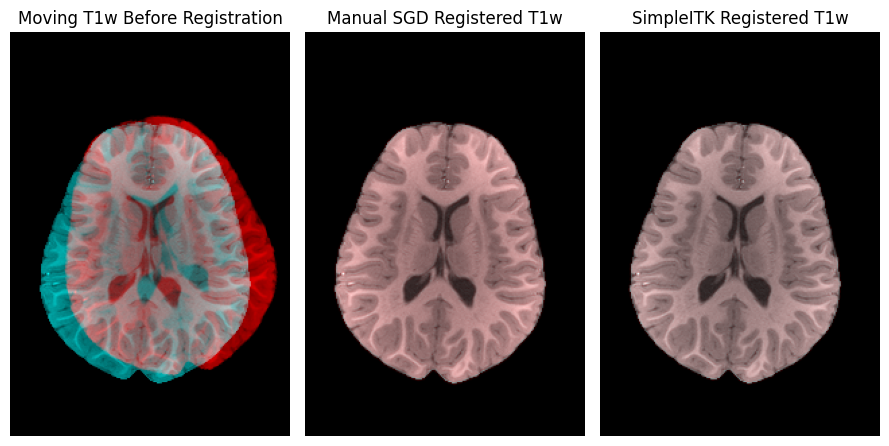

In [29]:
# test cell
# Try Similarity metrics
fixed_image_sitk_compare_t1 = imageNormalization(t1_coronal)

comparison_images_t1 = [
    imageNormalization(t1_transformed_coronal),
    imageNormalization(registered_t1_coronal_ssd),
    imageNormalization(registered_t1_coronal_sitk),
]
comparison_titles_t1 = [
    "Moving T1w Before Registration",
    "Manual SGD Registered T1w",
    "SimpleITK Registered T1w",
]

similarity_results_sitk_compare = compute_registration_similarity_table(
    fixed_image=fixed_image_sitk_compare_t1,
    moving_images=comparison_images_t1,
    titles=comparison_titles_t1,
    metrics=("SSD", "RIU", "CC", "MI"),
)
print_registration_similarity_table(
    similarity_results_sitk_compare,
    metrics=("SSD", "RIU", "CC", "MI"),
)

overlap_results_sitk_compare = compute_registration_overlap_table(
    fixed_image=fixed_image_sitk_compare_t1,
    moving_images=comparison_images_t1,
    titles=comparison_titles_t1,
    threshold=0,
)
print_overlap_table(overlap_results_sitk_compare)

show_registration_comparison(
    fixed_image_sitk_compare_t1,
    comparison_images_t1,
    comparison_titles_t1,
    cols=3,
)


还是标准库的结果量化指标更好一点。不过从最后的掩膜图来看，看不出什么差异。

#### 3.2.2 比较跨模态配准结果

Similarity metrics between fixed image and registration results:
Image                                        SSD           RIU            CC            MI
------------------------------------------------------------------------------------------------
Moving T2w Before Registration        336.013122      3.693065      0.334074      0.169476
Manual SGD Registered T2w              88.587551      0.127843      0.936636      1.550237
SimpleITK Registered T2w              293.438806     23.428825      0.529350      0.403201

Degree of Overlap between fixed image and registered image:
Image                                Degree of Overlap
------------------------------------------------------
Moving T2w Before Registration                0.878892
Manual SGD Registered T2w                     0.975276
SimpleITK Registered T2w                      0.961624



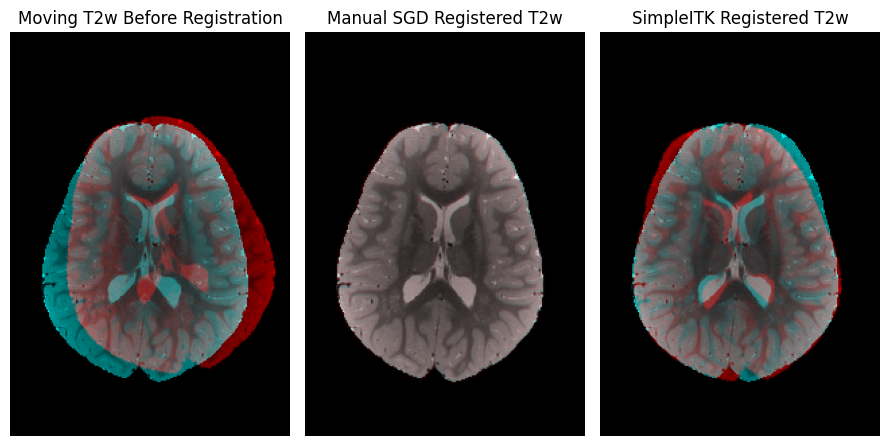

In [30]:
# test cell
# Try Similarity metrics
fixed_image_sitk_compare_t2 = imageNormalization(t2_coronal)

comparison_images_t2 = [
    imageNormalization(t2_transformed_coronal),
    imageNormalization(registered_t2_coronal_riu),
    imageNormalization(registered_t2_coronal_sitk),
]
comparison_titles_t2 = [
    "Moving T2w Before Registration",
    "Manual SGD Registered T2w",
    "SimpleITK Registered T2w",
]

similarity_results_sitk_compare = compute_registration_similarity_table(
    fixed_image=fixed_image_sitk_compare_t2,
    moving_images=comparison_images_t2,
    titles=comparison_titles_t2,
    metrics=("SSD", "RIU", "CC", "MI"),
)
print_registration_similarity_table(
    similarity_results_sitk_compare,
    metrics=("SSD", "RIU", "CC", "MI"),
)

overlap_results_sitk_compare = compute_registration_overlap_table(
    fixed_image=fixed_image_sitk_compare_t2,
    moving_images=comparison_images_t2,
    titles=comparison_titles_t2,
    threshold=0,
)
print_overlap_table(overlap_results_sitk_compare)

show_registration_comparison(
    fixed_image_sitk_compare_t2,
    comparison_images_t2,
    comparison_titles_t2,
    cols=3,
)


只能说调参数还是有用的，经过调参之后的跨模态配准（基于 RIU 指标）得到的配准图像更好。